In [1]:
# ============================================================
# SECTION 1: ENVIRONMENT & REPRODUCIBILITY
# ============================================================

import os
import sys
import random
import json
import zipfile
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K

# ---- Global config (used throughout the notebook) ----
SEED = 42
N_PATIENTS = 150          # <-- final decision: 150 patients for this run
IMG_SIZE = 160             # resize target (160x160)
TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = 0.70, 0.15, 0.15   # 105/22/23 approx

def set_global_seed(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(SEED)

# ---- Version / environment info ----
print("=" * 60)
print("ENVIRONMENT REPORT")
print("=" * 60)
print(f"Run timestamp        : {datetime.now().isoformat()}")
print(f"Python version        : {sys.version.split()[0]}")
print(f"TensorFlow version    : {tf.__version__}")
print(f"Keras version         : {keras.__version__}")
print(f"NumPy version         : {np.__version__}")
print(f"Pandas version        : {pd.__version__}")
print(f"Global random seed    : {SEED}")
print(f"Target patient count  : {N_PATIENTS}")
print(f"Image size            : {IMG_SIZE}x{IMG_SIZE}")
print(f"Split ratio           : {TRAIN_SPLIT}/{VAL_SPLIT}/{TEST_SPLIT}")

# ---- GPU check ----
gpus = tf.config.list_physical_devices('GPU')
print("-" * 60)
if gpus:
    print(f"GPU DETECTED: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  -> {gpu}")
    try:
        details = tf.config.experimental.get_device_details(gpus[0])
        print(f"  GPU details: {details}")
    except Exception as e:
        print(f"  (Could not fetch detailed GPU info: {e})")
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as e:
            print(f"  Memory growth setting failed: {e}")
else:
    print("WARNING: No GPU detected. Runtime > Change runtime type > T4 GPU")
print("=" * 60)

ENVIRONMENT REPORT
Run timestamp        : 2026-09-19T18:02:42.661846
Python version        : 3.13.15
TensorFlow version    : 2.20.0
Keras version         : 3.13.2
NumPy version         : 2.1.3
Pandas version        : 2.2.3
Global random seed    : 42
Target patient count  : 150
Image size            : 160x160
Split ratio           : 0.7/0.15/0.15
------------------------------------------------------------
GPU DETECTED: 1 device(s)
  -> PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  GPU details: {'compute_capability': (7, 5), 'device_name': 'Tesla T4'}


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ---- Project paths ----
PROJECT_ROOT   = Path('/content/drive/MyDrive/BrainTumor_project/dataset')
DATASET_DIR    = Path("/content/drive/MyDrive/Brain/BraTS2020_training_data/content/data")  # pre-extracted, use directly
ARTIFACTS_DIR  = PROJECT_ROOT / 'artifacts'                # selected IDs, split IDs, logs
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'              # model weights (survive disconnects)
RESULTS_DIR    = PROJECT_ROOT / 'results'                  # metrics, plots, PNGs for paper

for d in [ARTIFACTS_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Dataset dir exists   : {DATASET_DIR.exists()}")
print(f"Dataset dir path     : {DATASET_DIR}")

print(f"\nArtifacts dir         : {ARTIFACTS_DIR}")
print(f"Checkpoints dir       : {CHECKPOINT_DIR}")
print(f"Results dir           : {RESULTS_DIR}")


Mounted at /content/drive
Dataset dir exists   : True
Dataset dir path     : /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data

Artifacts dir         : /content/drive/MyDrive/BrainTumor_project/dataset/artifacts
Checkpoints dir       : /content/drive/MyDrive/BrainTumor_project/dataset/checkpoints
Results dir           : /content/drive/MyDrive/BrainTumor_project/dataset/results


In [3]:
# ============================================================
# SECTION 2: DATASET (already extracted, no unzip needed)
# ============================================================

import time

def list_dir_retry(path, retries=5, delay=4):
    """
    Google Drive's FUSE mount can throw transient 'Input/output error' (Errno 5)
    when listing very large folders (this dataset has ~45k files in one dir).
    Retries with a short backoff instead of failing the whole cell.
    Returns a list of entry names (not full listing objects).
    """
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            with os.scandir(path) as it:
                return [entry.name for entry in it]
        except OSError as e:
            last_err = e
            print(f"  Drive I/O error on attempt {attempt}/{retries}: {e}")
            if attempt < retries:
                time.sleep(delay)
    raise last_err

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"DATASET_DIR not found: {DATASET_DIR}")

_names = list_dir_retry(DATASET_DIR)

if not _names:
    raise FileNotFoundError(f"DATASET_DIR is empty: {DATASET_DIR}")

print(f"Using pre-extracted dataset at {DATASET_DIR}")
print(f"Top-level items: {len(_names)}")

# Show a handful of entries without forcing a full sort of ~45k items
print("\nSample dataset contents (first 10 entries):")
for name in _names[:10]:
    full_path = DATASET_DIR / name
    print(f"  {'[DIR] ' if full_path.is_dir() else '[FILE]'} {name}")


  Drive I/O error on attempt 1/5: [Errno 5] Input/output error: '/content/drive/MyDrive/Brain/BraTS2020_training_data/content/data'
Using pre-extracted dataset at /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data
Top-level items: 45451

Sample dataset contents (first 10 entries):
  [FILE] volume_359_slice_45.h5
  [FILE] volume_359_slice_12.h5
  [FILE] volume_359_slice_114.h5
  [FILE] volume_359_slice_25.h5
  [FILE] volume_359_slice_117.h5
  [FILE] volume_359_slice_77.h5
  [FILE] volume_359_slice_62.h5
  [FILE] volume_359_slice_42.h5
  [FILE] volume_359_slice_48.h5
  [FILE] volume_359_slice_18.h5


In [4]:
# ---- Auto-detect patient folder structure ----
# NOTE: this Kaggle-preprocessed BraTS2020 dataset is a flat folder of .h5 slice
# files (volume_XXX_slice_YYY.h5), not per-patient subfolders with t1/t1ce/t2/flair/seg
# files. So this will correctly report 0 patient folders -- that's expected, not a bug.
# Real volume/patient detection happens in the next cell via filename parsing.

def find_patient_dirs(root: Path):
    """Walk the extracted tree and find directories that look like patient folders
    (i.e. contain modality files: t1, t1ce, t2, flair, seg)."""
    modality_keys = ['t1', 't1ce', 't2', 'flair', 'seg']
    patient_dirs = []
    for dirpath, dirnames, filenames in os.walk(root):
        lower_files = [f.lower() for f in filenames]
        hits = sum(any(mk in f for f in lower_files) for mk in modality_keys)
        if hits >= 3:
            patient_dirs.append(Path(dirpath))
    return sorted(patient_dirs)

def safe_walk_top_level(root: Path, retries=5, delay=4):
    """Retry-safe single-level directory read (avoids Drive FUSE I/O errors)."""
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            with os.scandir(root) as it:
                entries = list(it)
            dirnames  = [e.name for e in entries if e.is_dir()]
            filenames = [e.name for e in entries if e.is_file()]
            return dirnames, filenames
        except OSError as e:
            last_err = e
            print(f"  Drive I/O error on attempt {attempt}/{retries}: {e}")
            if attempt < retries:
                time.sleep(delay)
    raise last_err

print("=" * 60)
print("DATASET VERIFICATION REPORT")
print("=" * 60)

try:
    patient_dirs = find_patient_dirs(DATASET_DIR)
except OSError as e:
    print(f"  Skipping recursive walk due to persistent Drive I/O error: {e}")
    patient_dirs = []

print(f"Total patient folders detected : {len(patient_dirs)}")

if len(patient_dirs) == 0:
    print("!! No patient folders auto-detected (expected for this flat .h5 dataset).")
    dirnames, filenames = safe_walk_top_level(DATASET_DIR)
    print(f"{DATASET_DIR.name}/  ({len(filenames)} files, {len(dirnames)} subdirs)")
else:
    sample = patient_dirs[0]
    print(f"\nSample patient folder: {sample}")
    print("Files inside:")
    for f in sorted(os.listdir(sample)):
        fp = sample / f
        size_mb = fp.stat().st_size / (1024**2) if fp.is_file() else 0
        print(f"  {f}  ({size_mb:.2f} MB)")

    required_modalities = ['t1', 't1ce', 't2', 'flair', 'seg']
    missing_report = []
    for pdir in patient_dirs:
        files_lower = [f.lower() for f in os.listdir(pdir)]
        has_t1    = any(('t1' in f and 't1ce' not in f) for f in files_lower)
        has_t1ce  = any('t1ce' in f for f in files_lower)
        has_t2    = any(('t2' in f and 'flair' not in f) for f in files_lower)
        has_flair = any('flair' in f for f in files_lower)
        has_seg   = any('seg' in f for f in files_lower)
        present = {'t1': has_t1, 't1ce': has_t1ce, 't2': has_t2, 'flair': has_flair, 'seg': has_seg}
        missing_mods = [k for k, v in present.items() if not v]
        if missing_mods:
            missing_report.append((pdir.name, missing_mods))

    print(f"\nPatients with ALL modalities present : {len(patient_dirs) - len(missing_report)}")
    print(f"Patients with MISSING modalities     : {len(missing_report)}")
    if missing_report:
        print("First 10 problem cases:")
        for name, miss in missing_report[:10]:
            print(f"  {name}: missing {miss}")

print("=" * 60)


DATASET VERIFICATION REPORT
Total patient folders detected : 0
!! No patient folders auto-detected (expected for this flat .h5 dataset).
data/  (45451 files, 0 subdirs)


In [5]:
# ============================================================
# INSPECT ACTUAL DATA FORMAT (Kaggle preprocessed BraTS2020 .h5)
# ============================================================
import h5py
import re

DATA_DIR = DATASET_DIR

def listdir_retry(path, retries=5, delay=4):
    """Retry-safe os.listdir for Drive's FUSE mount on very large folders."""
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            return os.listdir(path)
        except OSError as e:
            last_err = e
            print(f"  Drive I/O error on attempt {attempt}/{retries}: {e}")
            if attempt < retries:
                time.sleep(delay)
    raise last_err

all_files = sorted(listdir_retry(DATA_DIR))

# Separate metadata CSVs from actual volume/slice .h5 files
csv_files = [f for f in all_files if f.endswith('.csv')]
h5_files  = [f for f in all_files if f.endswith('.h5')]

print(f"Total files in data dir : {len(all_files)}")
print(f"CSV metadata files      : {csv_files}")
print(f"Total .h5 slice files   : {len(h5_files)}")

# ---- Extract volume (patient) IDs from filenames ----
pattern = re.compile(r'volume_(\d+)_slice_(\d+)\.h5')

volume_ids = set()
slice_counts = {}
for f in h5_files:
    m = pattern.match(f)
    if m:
        vid = int(m.group(1))
        volume_ids.add(vid)
        slice_counts[vid] = slice_counts.get(vid, 0) + 1
    else:
        print(f"  !! Filename didn't match pattern: {f}")

volume_ids = sorted(volume_ids)
print(f"\nUnique volumes (patients) detected : {len(volume_ids)}")
print(f"Volume ID range                     : min={min(volume_ids)}, max={max(volume_ids)}")
print(f"Slice count per volume (first 5)    : { {k: slice_counts[k] for k in volume_ids[:5]} }")
print(f"Slice count stats -> min={min(slice_counts.values())}, "
      f"max={max(slice_counts.values())}, "
      f"mean={np.mean(list(slice_counts.values())):.1f}")

# ---- Inspect one actual .h5 slice file's internal structure ----
sample_file = DATA_DIR / h5_files[0]
print(f"\nInspecting sample file: {sample_file.name}")
with h5py.File(sample_file, 'r') as f:
    print("Keys inside h5 file:", list(f.keys()))
    for key in f.keys():
        arr = f[key][:]
        print(f"  '{key}' -> shape={arr.shape}, dtype={arr.dtype}, "
              f"min={arr.min():.4f}, max={arr.max():.4f}, "
              f"unique_vals(sample)={np.unique(arr)[:10] if arr.size < 1e6 else 'too large'}")

# ---- Peek at metadata CSVs (may tell us HGG/LGG, survival, patient name mapping) ----
print("\n--- meta_data.csv (first 5 rows) ---")
print(pd.read_csv(DATA_DIR / 'meta_data.csv').head())

print("\n--- name_mapping.csv (first 5 rows) ---")
print(pd.read_csv(DATA_DIR / 'name_mapping.csv').head())

print("\n--- survival_info.csv (first 5 rows) ---")
print(pd.read_csv(DATA_DIR / 'survival_info.csv').head())


Total files in data dir : 45451
CSV metadata files      : ['meta_data.csv', 'name_mapping.csv', 'survival_info.csv']
Total .h5 slice files   : 45448

Unique volumes (patients) detected : 294
Volume ID range                     : min=1, max=365
Slice count per volume (first 5)    : {1: 155, 2: 155, 10: 155, 11: 155, 12: 155}
Slice count stats -> min=33, max=155, mean=154.6

Inspecting sample file: volume_100_slice_0.h5
Keys inside h5 file: ['image', 'mask']
  'image' -> shape=(240, 240, 4), dtype=float64, min=0.0000, max=0.0000, unique_vals(sample)=[0.]
  'mask' -> shape=(240, 240, 3), dtype=uint8, min=0.0000, max=0.0000, unique_vals(sample)=[0]

--- meta_data.csv (first 5 rows) ---
                           slice_path  target  volume  slice
0  /content/data/volume_41_slice_0.h5       0      41      0
1  /content/data/volume_41_slice_1.h5       0      41      1
2  /content/data/volume_41_slice_2.h5       0      41      2
3  /content/data/volume_41_slice_3.h5       0      41      3
4  /

In [ ]:
# ============================================================
# DEEPER VERIFICATION: target column, grade mapping, real slice
# ============================================================

meta_df = pd.read_csv(DATA_DIR / 'meta_data.csv')
name_map_df = pd.read_csv(DATA_DIR / 'name_mapping.csv')

print(f"meta_data.csv total rows       : {len(meta_df)}")
print(f"meta_data.csv columns          : {list(meta_df.columns)}")
print(f"target value counts            :\n{meta_df['target'].value_counts()}")
print(f"Unique volumes in meta_data    : {meta_df['volume'].nunique()}")

# ---- Verify target==1 actually means tumor present (cross check with mask) ----
sample_row = meta_df[meta_df['target'] == 1].iloc[0]
check_file = DATA_DIR / f"volume_{sample_row['volume']}_slice_{sample_row['slice']}.h5"
with h5py.File(check_file, 'r') as f:
    img = f['image'][:]
    msk = f['mask'][:]
print(f"\nCheck file (target=1): {check_file.name}")
print(f"  image -> min={img.min():.4f}, max={img.max():.4f}, mean={img.mean():.4f}")
print(f"  mask  -> min={msk.min()}, max={msk.max()}, nonzero_pixels={np.count_nonzero(msk)}")

# ---- name_mapping.csv: total rows + does it align with volume IDs 1-369? ----
print(f"\nname_mapping.csv total rows    : {len(name_map_df)}")
print(f"Grade distribution              :\n{name_map_df['Grade'].value_counts()}")

# Try mapping: does row index (1-based) align with volume ID via BraTS20_Training_XXX?
name_map_df['volume_id_guess'] = name_map_df['BraTS_2020_subject_ID'].str.extract(r'(\d+)$').astype(int)
print("\nFirst 5 rows with guessed volume_id:")
print(name_map_df[['Grade', 'BraTS_2020_subject_ID', 'volume_id_guess']].head())
print(f"\nvolume_id_guess range: min={name_map_df['volume_id_guess'].min()}, "
      f"max={name_map_df['volume_id_guess'].max()}")
print(f"Does volume_id_guess match unique volumes count? "
      f"{sorted(name_map_df['volume_id_guess'].tolist()) == list(range(1, 370))}")

# ---- Merge grade into meta_data for future stratified sampling ----
grade_lookup = name_map_df.set_index('volume_id_guess')['Grade'].to_dict()
meta_df['grade'] = meta_df['volume'].map(grade_lookup)
print(f"\nGrade merge success rate: {meta_df['grade'].notna().mean()*100:.1f}%")
print(f"Grade distribution after merge (per-slice):\n{meta_df['grade'].value_counts()}")

# Per-volume grade distribution (should be 369 unique)
per_volume_grade = meta_df.drop_duplicates('volume')[['volume', 'grade']]
print(f"\nPer-volume grade distribution:\n{per_volume_grade['grade'].value_counts()}")

meta_data.csv total rows       : 57195
meta_data.csv columns          : ['slice_path', 'target', 'volume', 'slice']
target value counts            :
target
0    32773
1    24422
Name: count, dtype: int64
Unique volumes in meta_data    : 369

Check file (target=1): volume_41_slice_25.h5
  image -> min=-0.3551, max=9.7872, mean=0.0000
  mask  -> min=0, max=1, nonzero_pixels=5

name_mapping.csv total rows    : 369
Grade distribution              :
Grade
HGG    293
LGG     76
Name: count, dtype: int64

First 5 rows with guessed volume_id:
  Grade BraTS_2020_subject_ID  volume_id_guess
0   HGG  BraTS20_Training_001                1
1   HGG  BraTS20_Training_002                2
2   HGG  BraTS20_Training_003                3
3   HGG  BraTS20_Training_004                4
4   HGG  BraTS20_Training_005                5

volume_id_guess range: min=1, max=369
Does volume_id_guess match unique volumes count? True

Grade merge success rate: 100.0%
Grade distribution after merge (per-slice):
grade


In [9]:
# ============================================================
# DEEPER VERIFICATION: target column, grade mapping, real slice
# ============================================================

meta_df = pd.read_csv(DATA_DIR / 'meta_data.csv')
name_map_df = pd.read_csv(DATA_DIR / 'name_mapping.csv')

print(f"meta_data.csv total rows       : {len(meta_df)}")
print(f"meta_data.csv columns          : {list(meta_df.columns)}")
print(f"target value counts            :\n{meta_df['target'].value_counts()}")
print(f"Unique volumes in meta_data    : {meta_df['volume'].nunique()}")

# ---- Check how many referenced files actually exist on disk ----
meta_df['h5_filename'] = meta_df['slice_path'].apply(lambda p: p.split('/')[-1])
existing_files = set(listdir_retry(DATA_DIR))  # reuse the retry helper from the dataset cell
meta_df['file_exists'] = meta_df['h5_filename'].isin(existing_files)

n_missing = (~meta_df['file_exists']).sum()
print(f"\nSlices referenced in meta_data.csv : {len(meta_df)}")
print(f"Slices actually present on disk    : {meta_df['file_exists'].sum()}")
print(f"Slices MISSING from disk           : {n_missing} ({n_missing/len(meta_df)*100:.1f}%)")

if n_missing > 0:
    print("\n!! WARNING: dataset in Drive is incomplete. Some volumes may have gaps.")
    volumes_with_missing = meta_df[~meta_df['file_exists']]['volume'].nunique()
    print(f"   Volumes affected: {volumes_with_missing} / {meta_df['volume'].nunique()}")

# ---- Verify target==1 actually means tumor present (cross check with mask) ----
# Use a row that we've confirmed actually exists on disk
sample_row = meta_df[(meta_df['target'] == 1) & (meta_df['file_exists'])].iloc[0]
check_file = DATA_DIR / sample_row['h5_filename']
with h5py.File(check_file, 'r') as f:
    img = f['image'][:]
    msk = f['mask'][:]
print(f"\nCheck file (target=1): {check_file.name}")
print(f"  image -> min={img.min():.4f}, max={img.max():.4f}, mean={img.mean():.4f}")
print(f"  mask  -> min={msk.min()}, max={msk.max()}, nonzero_pixels={np.count_nonzero(msk)}")

# ---- name_mapping.csv: total rows + does it align with volume IDs 1-369? ----
print(f"\nname_mapping.csv total rows    : {len(name_map_df)}")
print(f"Grade distribution              :\n{name_map_df['Grade'].value_counts()}")

name_map_df['volume_id_guess'] = name_map_df['BraTS_2020_subject_ID'].str.extract(r'(\d+)$').astype(int)
print("\nFirst 5 rows with guessed volume_id:")
print(name_map_df[['Grade', 'BraTS_2020_subject_ID', 'volume_id_guess']].head())
print(f"\nvolume_id_guess range: min={name_map_df['volume_id_guess'].min()}, "
      f"max={name_map_df['volume_id_guess'].max()}")
print(f"Does volume_id_guess match unique volumes count? "
      f"{sorted(name_map_df['volume_id_guess'].tolist()) == list(range(1, 370))}")

# ---- Merge grade into meta_data for future stratified sampling ----
grade_lookup = name_map_df.set_index('volume_id_guess')['Grade'].to_dict()
meta_df['grade'] = meta_df['volume'].map(grade_lookup)
print(f"\nGrade merge success rate: {meta_df['grade'].notna().mean()*100:.1f}%")
print(f"Grade distribution after merge (per-slice):\n{meta_df['grade'].value_counts()}")

# Per-volume grade distribution (should be 369 unique)
per_volume_grade = meta_df.drop_duplicates('volume')[['volume', 'grade']]
print(f"\nPer-volume grade distribution:\n{per_volume_grade['grade'].value_counts()}")

meta_data.csv total rows       : 57195
meta_data.csv columns          : ['slice_path', 'target', 'volume', 'slice']
target value counts            :
target
0    32773
1    24422
Name: count, dtype: int64
Unique volumes in meta_data    : 369

Slices referenced in meta_data.csv : 57195
Slices actually present on disk    : 45448
Slices MISSING from disk           : 11747 (20.5%)

!! WARNING: dataset in Drive is incomplete. Some volumes may have gaps.
   Volumes affected: 76 / 369

Check file (target=1): volume_185_slice_26.h5
  image -> min=-0.4190, max=7.3618, mean=0.0000
  mask  -> min=0, max=1, nonzero_pixels=1

name_mapping.csv total rows    : 369
Grade distribution              :
Grade
HGG    293
LGG     76
Name: count, dtype: int64

First 5 rows with guessed volume_id:
  Grade BraTS_2020_subject_ID  volume_id_guess
0   HGG  BraTS20_Training_001                1
1   HGG  BraTS20_Training_002                2
2   HGG  BraTS20_Training_003                3
3   HGG  BraTS20_Training_004

In [11]:
# ============================================================
# SECTION 3: PATIENT SELECTION — 60 PATIENTS (STRATIFIED BY GRADE)
# ============================================================

N_PATIENTS = 60   # <-- final decision: 60 patients
print(f"Target patient count: {N_PATIENTS}")

# per_volume_grade already built in previous cell: columns ['volume', 'grade']
grade_counts_full = per_volume_grade['grade'].value_counts()
print(f"\nFull dataset grade distribution (369 patients):\n{grade_counts_full}")
print(f"Full dataset proportions:\n{(grade_counts_full / grade_counts_full.sum() * 100).round(1)}")

# ---- Stratified sampling: preserve HGG:LGG ratio in the 60-patient subset ----
hgg_pool = per_volume_grade[per_volume_grade['grade'] == 'HGG']['volume'].tolist()
lgg_pool = per_volume_grade[per_volume_grade['grade'] == 'LGG']['volume'].tolist()

n_hgg = round(N_PATIENTS * len(hgg_pool) / len(per_volume_grade))
n_lgg = N_PATIENTS - n_hgg   # ensures exact total

print(f"\nStratified target -> HGG: {n_hgg}, LGG: {n_lgg}, total: {n_hgg + n_lgg}")

rng = random.Random(SEED)   # dedicated RNG instance, seeded, for full reproducibility
selected_hgg = sorted(rng.sample(hgg_pool, n_hgg))
selected_lgg = sorted(rng.sample(lgg_pool, n_lgg))

selected_patients = sorted(selected_hgg + selected_lgg)
print(f"\nTotal selected patients: {len(selected_patients)}")
print(f"Selected volume IDs (first 15): {selected_patients[:15]}")

# ---- Save selected patient IDs + metadata for reproducibility / defense ----
selected_df = per_volume_grade[per_volume_grade['volume'].isin(selected_patients)].copy()
selected_df = selected_df.sort_values('volume').reset_index(drop=True)

print(f"\nSelected subset grade distribution:\n{selected_df['grade'].value_counts()}")
print(f"Selected subset proportions:\n{(selected_df['grade'].value_counts() / len(selected_df) * 100).round(1)}")

selection_record = {
    "selection_date": datetime.now().isoformat(),
    "seed": SEED,
    "n_patients_selected": N_PATIENTS,
    "n_hgg": n_hgg,
    "n_lgg": n_lgg,
    "method": "stratified random sampling by tumor grade, preserving full-dataset HGG:LGG ratio",
    "selected_volume_ids": selected_patients
}

with open(ARTIFACTS_DIR / 'selected_patients.json', 'w') as f:
    json.dump(selection_record, f, indent=2)

selected_df.to_csv(ARTIFACTS_DIR / 'selected_patients.csv', index=False)

print(f"\nSaved: {ARTIFACTS_DIR / 'selected_patients.json'}")
print(f"Saved: {ARTIFACTS_DIR / 'selected_patients.csv'}")

Target patient count: 60

Full dataset grade distribution (369 patients):
grade
HGG    293
LGG     76
Name: count, dtype: int64
Full dataset proportions:
grade
HGG    79.4
LGG    20.6
Name: count, dtype: float64

Stratified target -> HGG: 48, LGG: 12, total: 60

Total selected patients: 60
Selected volume IDs (first 15): [1, 9, 24, 26, 27, 29, 38, 39, 40, 54, 58, 63, 64, 76, 81]

Selected subset grade distribution:
grade
HGG    48
LGG    12
Name: count, dtype: int64
Selected subset proportions:
grade
HGG    80.0
LGG    20.0
Name: count, dtype: float64

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/artifacts/selected_patients.json
Saved: /content/drive/MyDrive/BrainTumor_project/dataset/artifacts/selected_patients.csv


In [13]:
# ============================================================
# SECTION 4: PATIENT-LEVEL TRAIN/VAL/TEST SPLIT (70/15/15)
# ============================================================

TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = 0.70, 0.15, 0.15

def stratified_split(patient_list, grade_lookup, train_ratio, val_ratio, test_ratio, seed):
    """Split patient IDs into train/val/test, stratified by grade, fully reproducible."""
    rng = random.Random(seed)

    hgg = sorted([p for p in patient_list if grade_lookup[p] == 'HGG'])
    lgg = sorted([p for p in patient_list if grade_lookup[p] == 'LGG'])

    def split_group(group):
        group = group.copy()
        rng.shuffle(group)
        n = len(group)
        n_train = round(n * train_ratio)
        n_val   = round(n * val_ratio)
        train = group[:n_train]
        val   = group[n_train:n_train + n_val]
        test  = group[n_train + n_val:]
        return train, val, test

    hgg_train, hgg_val, hgg_test = split_group(hgg)
    lgg_train, lgg_val, lgg_test = split_group(lgg)

    train = sorted(hgg_train + lgg_train)
    val   = sorted(hgg_val + lgg_val)
    test  = sorted(hgg_test + lgg_test)
    return train, val, test

grade_lookup_dict = dict(zip(selected_df['volume'], selected_df['grade']))

train_ids, val_ids, test_ids = stratified_split(
    selected_patients, grade_lookup_dict,
    TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT, seed=SEED
)

# ---- Sanity checks: no overlap, all patients accounted for ----
assert set(train_ids) & set(val_ids) == set(), "Overlap between train and val!"
assert set(train_ids) & set(test_ids) == set(), "Overlap between train and test!"
assert set(val_ids) & set(test_ids) == set(), "Overlap between val and test!"
assert len(train_ids) + len(val_ids) + len(test_ids) == len(selected_patients), "Patient count mismatch!"

print("=" * 60)
print("PATIENT-LEVEL SPLIT REPORT")
print("=" * 60)
print(f"Train : {len(train_ids)} patients")
print(f"Val   : {len(val_ids)} patients")
print(f"Test  : {len(test_ids)} patients")
print(f"Total : {len(train_ids) + len(val_ids) + len(test_ids)} patients")

for name, ids in [('Train', train_ids), ('Val', val_ids), ('Test', test_ids)]:
    grades = [grade_lookup_dict[i] for i in ids]
    hgg_n = grades.count('HGG')
    lgg_n = grades.count('LGG')
    print(f"\n{name} set grade breakdown -> HGG: {hgg_n}, LGG: {lgg_n} "
          f"(HGG% = {hgg_n/len(ids)*100:.1f}%)")

print("=" * 60)

# ---- No-overlap explicit confirmation ----
print(f"\nOverlap check (should all be empty sets):")
print(f"  Train ∩ Val  : {set(train_ids) & set(val_ids)}")
print(f"  Train ∩ Test : {set(train_ids) & set(test_ids)}")
print(f"  Val ∩ Test   : {set(val_ids) & set(test_ids)}")

# ---- Save split IDs ----
split_record = {
    "split_date": datetime.now().isoformat(),
    "seed": SEED,
    "split_ratio": {"train": TRAIN_SPLIT, "val": VAL_SPLIT, "test": TEST_SPLIT},
    "method": "stratified by tumor grade, patient-level (no slice leakage across sets)",
    "train_ids": train_ids,
    "val_ids": val_ids,
    "test_ids": test_ids,
    "counts": {"train": len(train_ids), "val": len(val_ids), "test": len(test_ids)}
}

with open(ARTIFACTS_DIR / 'patient_split.json', 'w') as f:
    json.dump(split_record, f, indent=2)

# Also save as CSV for easy viva/paper reference
split_df = pd.DataFrame(
    [(pid, 'train', grade_lookup_dict[pid]) for pid in train_ids] +
    [(pid, 'val',   grade_lookup_dict[pid]) for pid in val_ids] +
    [(pid, 'test',  grade_lookup_dict[pid]) for pid in test_ids],
    columns=['volume_id', 'split', 'grade']
).sort_values('volume_id').reset_index(drop=True)

split_df.to_csv(ARTIFACTS_DIR / 'patient_split.csv', index=False)

print(f"\nSaved: {ARTIFACTS_DIR / 'patient_split.json'}")
print(f"Saved: {ARTIFACTS_DIR / 'patient_split.csv'}")
print("\nSplit dataframe preview:")
print(split_df.head(10))

PATIENT-LEVEL SPLIT REPORT
Train : 42 patients
Val   : 9 patients
Test  : 9 patients
Total : 60 patients

Train set grade breakdown -> HGG: 34, LGG: 8 (HGG% = 81.0%)

Val set grade breakdown -> HGG: 7, LGG: 2 (HGG% = 77.8%)

Test set grade breakdown -> HGG: 7, LGG: 2 (HGG% = 77.8%)

Overlap check (should all be empty sets):
  Train ∩ Val  : set()
  Train ∩ Test : set()
  Val ∩ Test   : set()

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/artifacts/patient_split.json
Saved: /content/drive/MyDrive/BrainTumor_project/dataset/artifacts/patient_split.csv

Split dataframe preview:
   volume_id  split grade
0          1  train   HGG
1          9   test   HGG
2         24    val   HGG
3         26  train   HGG
4         27  train   HGG
5         29    val   HGG
6         38    val   HGG
7         39   test   HGG
8         40   test   HGG
9         54  train   HGG


In [15]:
# ============================================================
# SECTION 5: PREPROCESSING — STEP 1: SLICE-LEVEL FILTERING
# ============================================================

# Map each volume to its split (train/val/test)
volume_to_split = dict(zip(split_df['volume_id'], split_df['split']))

# Filter meta_data.csv to ONLY our 60 selected patients
meta_selected = meta_df[meta_df['volume'].isin(selected_patients)].copy()
meta_selected['split'] = meta_selected['volume'].map(volume_to_split)

print(f"Total slices across 60 selected patients : {len(meta_selected)}")
print(f"  (expected: 60 x 155 = {60*155})")

# ---- Tumor-positive slice counts (target == 1) per split ----
print("\n" + "=" * 60)
print("SLICE COUNTS PER SPLIT")
print("=" * 60)

slice_summary = {}
for split_name in ['train', 'val', 'test']:
    subset = meta_selected[meta_selected['split'] == split_name]
    total_slices = len(subset)
    tumor_pos = (subset['target'] == 1).sum()
    tumor_neg = (subset['target'] == 0).sum()
    slice_summary[split_name] = {
        'total_slices': int(total_slices),
        'tumor_positive': int(tumor_pos),
        'tumor_negative': int(tumor_neg),
        'n_patients': subset['volume'].nunique()
    }
    print(f"\n{split_name.upper()}:")
    print(f"  Patients            : {subset['volume'].nunique()}")
    print(f"  Total slices        : {total_slices}")
    print(f"  Tumor-positive      : {tumor_pos}  ({tumor_pos/total_slices*100:.1f}%)")
    print(f"  Tumor-negative      : {tumor_neg}  ({tumor_neg/total_slices*100:.1f}%)")

print("\n" + "=" * 60)
total_tumor_pos_all = sum(v['tumor_positive'] for v in slice_summary.values())
print(f"TOTAL tumor-positive slices (train+val+test) used for training/eval: {total_tumor_pos_all}")
print("=" * 60)

# Save this summary — this is the ACTUAL count notebook produced, not guessed
with open(ARTIFACTS_DIR / 'slice_counts_summary.json', 'w') as f:
    json.dump(slice_summary, f, indent=2)
print(f"\nSaved: {ARTIFACTS_DIR / 'slice_counts_summary.json'}")

# Build the actual slice-level dataframes we'll use for the dataloader
train_slices_df = meta_selected[(meta_selected['split'] == 'train') & (meta_selected['target'] == 1)].reset_index(drop=True)
val_slices_df   = meta_selected[(meta_selected['split'] == 'val')   & (meta_selected['target'] == 1)].reset_index(drop=True)
test_slices_df  = meta_selected[(meta_selected['split'] == 'test')  & (meta_selected['target'] == 1)].reset_index(drop=True)

train_slices_df.to_csv(ARTIFACTS_DIR / 'train_slices.csv', index=False)
val_slices_df.to_csv(ARTIFACTS_DIR / 'val_slices.csv', index=False)
test_slices_df.to_csv(ARTIFACTS_DIR / 'test_slices.csv', index=False)
print("Saved: train_slices.csv, val_slices.csv, test_slices.csv")

Total slices across 60 selected patients : 9300
  (expected: 60 x 155 = 9300)

SLICE COUNTS PER SPLIT

TRAIN:
  Patients            : 42
  Total slices        : 6510
  Tumor-positive      : 2978  (45.7%)
  Tumor-negative      : 3532  (54.3%)

VAL:
  Patients            : 9
  Total slices        : 1395
  Tumor-positive      : 578  (41.4%)
  Tumor-negative      : 817  (58.6%)

TEST:
  Patients            : 9
  Total slices        : 1395
  Tumor-positive      : 564  (40.4%)
  Tumor-negative      : 831  (59.6%)

TOTAL tumor-positive slices (train+val+test) used for training/eval: 4120

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/artifacts/slice_counts_summary.json
Saved: train_slices.csv, val_slices.csv, test_slices.csv


Sample: /content/data/volume_190_slice_42.h5
Preprocessed image shape : (160, 160, 4), dtype: float32
  per-channel min/max after normalization:
    channel 0: min=0.000, max=1.000
    channel 1: min=0.000, max=1.000
    channel 2: min=0.000, max=1.000
    channel 3: min=0.000, max=1.000
Preprocessed mask shape  : (160, 160, 1), dtype: float32
  mask unique values     : [0. 1.]
  mask tumor pixel count : 1


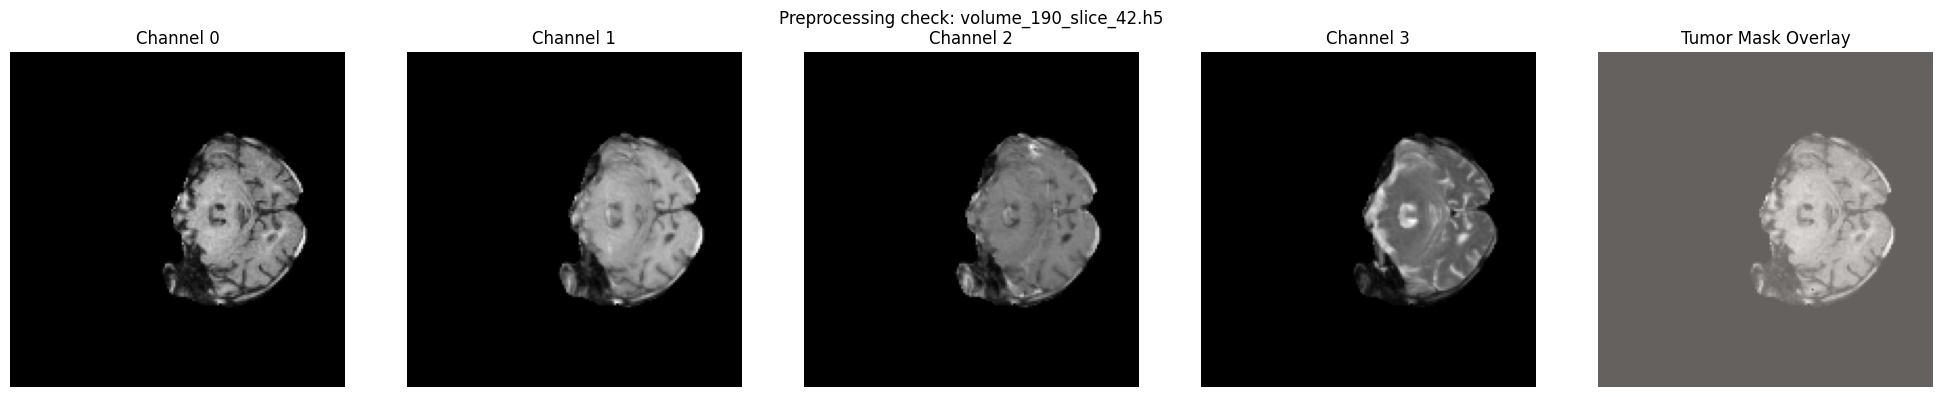


Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/preprocessing_sanity_check.png


In [16]:
# ============================================================
# SECTION 5: PREPROCESSING — STEP 3: CORE PREPROCESSING FUNCTION
# ============================================================

IMG_SIZE = 160   # already set in Section 1

def load_and_preprocess(slice_path_relative):
    """
    Loads one .h5 slice file, returns:
      image: (IMG_SIZE, IMG_SIZE, 4) float32 -- 4 stacked MRI modalities
      mask : (IMG_SIZE, IMG_SIZE, 1) float32 -- binary tumor mask (0/1)
    """
    fname = slice_path_relative.split('/')[-1]
    fpath = DATA_DIR / fname
    with h5py.File(fpath, 'r') as f:
        img = f['image'][:].astype(np.float32)   # (240, 240, 4)
        msk = f['mask'][:].astype(np.float32)     # (240, 240, 3)

    # ---- Binary mask: any of the 3 tumor sub-regions -> tumor pixel ----
    binary_mask = (msk.sum(axis=-1, keepdims=True) > 0).astype(np.float32)  # (240, 240, 1)

    # ---- Resize to IMG_SIZE x IMG_SIZE ----
    img_resized  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method='bilinear').numpy()
    mask_resized = tf.image.resize(binary_mask, [IMG_SIZE, IMG_SIZE], method='nearest').numpy()
    mask_resized = (mask_resized > 0.5).astype(np.float32)  # re-binarize after resize interpolation

    # ---- Per-slice per-channel normalization (min-max to [0,1]) ----
    # Data is already roughly z-scored, but we rescale per-channel to a clean [0,1]
    # range so the network sees a consistent input distribution regardless of
    # per-scan intensity variation.
    img_norm = np.zeros_like(img_resized, dtype=np.float32)
    for c in range(img_resized.shape[-1]):
        ch = img_resized[..., c]
        ch_min, ch_max = ch.min(), ch.max()
        if ch_max > ch_min:
            img_norm[..., c] = (ch - ch_min) / (ch_max - ch_min)
        else:
            img_norm[..., c] = ch  # flat channel (all zero), leave as-is

    return img_norm.astype(np.float32), mask_resized.astype(np.float32)


# ---- Sanity check on one tumor-positive sample ----
test_row = train_slices_df.iloc[0]
img_out, mask_out = load_and_preprocess(test_row['slice_path'])

print(f"Sample: {test_row['slice_path']}")
print(f"Preprocessed image shape : {img_out.shape}, dtype: {img_out.dtype}")
print(f"  per-channel min/max after normalization:")
for c in range(img_out.shape[-1]):
    print(f"    channel {c}: min={img_out[...,c].min():.3f}, max={img_out[...,c].max():.3f}")
print(f"Preprocessed mask shape  : {mask_out.shape}, dtype: {mask_out.dtype}")
print(f"  mask unique values     : {np.unique(mask_out)}")
print(f"  mask tumor pixel count : {int(mask_out.sum())}")

# ---- Visualize: 4 modalities + mask overlay ----
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
modality_names = ['Channel 0', 'Channel 1', 'Channel 2', 'Channel 3']
for i in range(4):
    axes[i].imshow(img_out[..., i], cmap='gray')
    axes[i].set_title(modality_names[i])
    axes[i].axis('off')
axes[4].imshow(img_out[..., 0], cmap='gray')
axes[4].imshow(mask_out[..., 0], cmap='Reds', alpha=0.4)
axes[4].set_title('Tumor Mask Overlay')
axes[4].axis('off')
plt.suptitle(f"Preprocessing check: {test_row['slice_path'].split('/')[-1]}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'preprocessing_sanity_check.png', dpi=150)
plt.show()
print(f"\nSaved: {RESULTS_DIR / 'preprocessing_sanity_check.png'}")

In [18]:
# ============================================================
# SECTION 5: PREPROCESSING — STEP 1: SLICE-LEVEL FILTERING
# ============================================================

# Map each volume to its split (train/val/test)
volume_to_split = dict(zip(split_df['volume_id'], split_df['split']))

# Filter meta_data.csv to ONLY our 60 selected patients
meta_selected = meta_df[meta_df['volume'].isin(selected_patients)].copy()
meta_selected['split'] = meta_selected['volume'].map(volume_to_split)

# ---- Drop rows whose .h5 file isn't actually present in Drive ----
existing_files = set(listdir_retry(DATA_DIR))  # reuse retry helper from dataset cell
meta_selected['h5_filename'] = meta_selected['slice_path'].apply(lambda p: p.split('/')[-1])
meta_selected['file_exists'] = meta_selected['h5_filename'].isin(existing_files)

n_missing_selected = (~meta_selected['file_exists']).sum()
print(f"Slices for 60 selected patients (before filtering missing) : {len(meta_selected)}")
print(f"  -> Missing from disk : {n_missing_selected} ({n_missing_selected/len(meta_selected)*100:.1f}%)")

meta_selected = meta_selected[meta_selected['file_exists']].drop(columns=['file_exists']).reset_index(drop=True)
print(f"  -> Remaining (usable): {len(meta_selected)}")

print(f"\nTotal usable slices across 60 selected patients : {len(meta_selected)}")

# ---- Tumor-positive slice counts (target == 1) per split ----
print("\n" + "=" * 60)
print("SLICE COUNTS PER SPLIT")
print("=" * 60)

slice_summary = {}
for split_name in ['train', 'val', 'test']:
    subset = meta_selected[meta_selected['split'] == split_name]
    total_slices = len(subset)
    tumor_pos = (subset['target'] == 1).sum()
    tumor_neg = (subset['target'] == 0).sum()
    slice_summary[split_name] = {
        'total_slices': int(total_slices),
        'tumor_positive': int(tumor_pos),
        'tumor_negative': int(tumor_neg),
        'n_patients': subset['volume'].nunique()
    }
    print(f"\n{split_name.upper()}:")
    print(f"  Patients            : {subset['volume'].nunique()}")
    print(f"  Total slices        : {total_slices}")
    print(f"  Tumor-positive      : {tumor_pos}  ({tumor_pos/total_slices*100:.1f}%)")
    print(f"  Tumor-negative      : {tumor_neg}  ({tumor_neg/total_slices*100:.1f}%)")

print("\n" + "=" * 60)
total_tumor_pos_all = sum(v['tumor_positive'] for v in slice_summary.values())
print(f"TOTAL tumor-positive slices (train+val+test) used for training/eval: {total_tumor_pos_all}")
print("=" * 60)

# Save this summary — this is the ACTUAL count notebook produced, not guessed
with open(ARTIFACTS_DIR / 'slice_counts_summary.json', 'w') as f:
    json.dump(slice_summary, f, indent=2)
print(f"\nSaved: {ARTIFACTS_DIR / 'slice_counts_summary.json'}")

# Build the actual slice-level dataframes we'll use for the dataloader
train_slices_df = meta_selected[(meta_selected['split'] == 'train') & (meta_selected['target'] == 1)].reset_index(drop=True)
val_slices_df   = meta_selected[(meta_selected['split'] == 'val')   & (meta_selected['target'] == 1)].reset_index(drop=True)
test_slices_df  = meta_selected[(meta_selected['split'] == 'test')  & (meta_selected['target'] == 1)].reset_index(drop=True)

train_slices_df.to_csv(ARTIFACTS_DIR / 'train_slices.csv', index=False)
val_slices_df.to_csv(ARTIFACTS_DIR / 'val_slices.csv', index=False)
test_slices_df.to_csv(ARTIFACTS_DIR / 'test_slices.csv', index=False)
print("Saved: train_slices.csv, val_slices.csv, test_slices.csv")

Slices for 60 selected patients (before filtering missing) : 9300
  -> Missing from disk : 1705 (18.3%)
  -> Remaining (usable): 7595

Total usable slices across 60 selected patients : 7595

SLICE COUNTS PER SPLIT

TRAIN:
  Patients            : 37
  Total slices        : 5735
  Tumor-positive      : 2626  (45.8%)
  Tumor-negative      : 3109  (54.2%)

VAL:
  Patients            : 8
  Total slices        : 1240
  Tumor-positive      : 490  (39.5%)
  Tumor-negative      : 750  (60.5%)

TEST:
  Patients            : 4
  Total slices        : 620
  Tumor-positive      : 251  (40.5%)
  Tumor-negative      : 369  (59.5%)

TOTAL tumor-positive slices (train+val+test) used for training/eval: 3367

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/artifacts/slice_counts_summary.json
Saved: train_slices.csv, val_slices.csv, test_slices.csv


In [19]:
# ============================================================
# SECTION 6: AUGMENTATION (TRAIN SET ONLY) — 7 TECHNIQUES
# ============================================================

def augment_image_mask(image, mask):
    """
    Applies 7 augmentations, each independently randomized:
      1. Random horizontal flip
      2. Random vertical flip
      3. Random rotation (90-degree increments, safe for paired image+mask)
      4. Random zoom (via central crop + resize)
      5. Random brightness shift (image only)
      6. Random contrast shift (image only)
      7. Additive Gaussian noise (image only)
    Applied identically to image+mask for spatial transforms (flip/rotate/zoom),
    and image-only for intensity transforms (brightness/contrast/noise) since
    masks are binary labels and must not be perturbed photometrically.
    """
    # ---- 1. Horizontal flip ----
    if tf.random.uniform([]) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # ---- 2. Vertical flip ----
    if tf.random.uniform([]) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # ---- 3. Random rotation (0/90/180/270 -- exact, no interpolation artifacts) ----
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)
    mask = tf.image.rot90(mask, k=k)

    # ---- 4. Random zoom (central crop 85-100% then resize back) ----
    if tf.random.uniform([]) > 0.5:
        crop_frac = tf.random.uniform([], minval=0.85, maxval=1.0)
        h = tf.cast(tf.cast(IMG_SIZE, tf.float32) * crop_frac, tf.int32)
        combined = tf.concat([image, mask], axis=-1)  # crop image+mask together
        combined = tf.image.random_crop(combined, size=[h, h, image.shape[-1] + mask.shape[-1]])
        combined = tf.image.resize(combined, [IMG_SIZE, IMG_SIZE], method='nearest')
        image = combined[..., :image.shape[-1]]
        mask = combined[..., image.shape[-1]:]
        mask = tf.cast(mask > 0.5, tf.float32)  # re-binarize after resize

    # ---- 5. Random brightness shift (image only) ----
    image = tf.image.random_brightness(image, max_delta=0.1)

    # ---- 6. Random contrast shift (image only) ----
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    # ---- 7. Additive Gaussian noise (image only) ----
    if tf.random.uniform([]) > 0.5:
        noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
        image = image + noise

    # Clip image back to valid [0,1] range after intensity augmentations
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.clip_by_value(mask, 0.0, 1.0)

    return image, mask


print("Augmentation function defined: 7 techniques")
print("  1. Horizontal flip")
print("  2. Vertical flip")
print("  3. Rotation (90-degree increments)")
print("  4. Random zoom (crop + resize)")
print("  5. Brightness shift")
print("  6. Contrast shift")
print("  7. Gaussian noise")
print("\nApplied to TRAIN set only. Val/Test remain clean (no augmentation).")

Augmentation function defined: 7 techniques
  1. Horizontal flip
  2. Vertical flip
  3. Rotation (90-degree increments)
  4. Random zoom (crop + resize)
  5. Brightness shift
  6. Contrast shift
  7. Gaussian noise

Applied to TRAIN set only. Val/Test remain clean (no augmentation).


In [20]:
# ============================================================
# tf.data DATALOADER
# ============================================================

BATCH_SIZE = 16

def make_generator(df):
    def gen():
        for _, row in df.iterrows():
            img, msk = load_and_preprocess(row['slice_path'])
            yield img, msk
    return gen

output_signature = (
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 4), dtype=tf.float32),
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
)

def build_dataset(df, split_name, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        make_generator(df),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 1000), seed=SEED, reshuffle_each_iteration=True)
    if split_name == 'train':
        ds = ds.map(augment_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_slices_df, 'train', shuffle=True)
val_ds   = build_dataset(val_slices_df,   'val',   shuffle=False)
test_ds  = build_dataset(test_slices_df,  'test',  shuffle=False)

print(f"Train dataset batches (approx) : {len(train_slices_df) // BATCH_SIZE}")
print(f"Val dataset batches (approx)   : {len(val_slices_df) // BATCH_SIZE}")
print(f"Test dataset batches (approx)  : {len(test_slices_df) // BATCH_SIZE}")

# ---- Sanity check: pull one batch from each ----
for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    for img_batch, mask_batch in ds.take(1):
        print(f"\n{name} batch -> image shape: {img_batch.shape}, mask shape: {mask_batch.shape}")
        print(f"  image range: [{img_batch.numpy().min():.3f}, {img_batch.numpy().max():.3f}]")
        print(f"  mask unique values: {np.unique(mask_batch.numpy())}")

Train dataset batches (approx) : 164
Val dataset batches (approx)   : 30
Test dataset batches (approx)  : 15

train batch -> image shape: (16, 160, 160, 4), mask shape: (16, 160, 160, 1)
  image range: [0.000, 1.000]
  mask unique values: [0. 1.]

val batch -> image shape: (16, 160, 160, 4), mask shape: (16, 160, 160, 1)
  image range: [0.000, 1.000]
  mask unique values: [0. 1.]

test batch -> image shape: (16, 160, 160, 4), mask shape: (16, 160, 160, 1)
  image range: [0.000, 1.000]
  mask unique values: [0. 1.]


In [21]:
# ============================================================
# SECTION 7: ATTENTION U-NET
# ============================================================

def conv_block(x, filters, name):
    x = layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal', name=f'{name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = layers.Activation('relu', name=f'{name}_relu1')(x)
    x = layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal', name=f'{name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)
    x = layers.Activation('relu', name=f'{name}_relu2')(x)
    return x

def attention_gate(x, g, filters, name):
    """
    Attention gate: suppresses irrelevant regions in skip-connection features `x`,
    guided by gating signal `g` from the coarser decoder level.
    """
    theta_x = layers.Conv2D(filters, 1, strides=1, padding='same', name=f'{name}_theta_x')(x)
    phi_g   = layers.Conv2D(filters, 1, strides=1, padding='same', name=f'{name}_phi_g')(g)
    add_xg  = layers.Add(name=f'{name}_add')([theta_x, phi_g])
    act_xg  = layers.Activation('relu', name=f'{name}_relu')(add_xg)
    psi     = layers.Conv2D(1, 1, strides=1, padding='same', name=f'{name}_psi')(act_xg)
    sigmoid_psi = layers.Activation('sigmoid', name=f'{name}_sigmoid')(psi)
    upsample_psi = layers.Multiply(name=f'{name}_mult')([x, sigmoid_psi])
    return upsample_psi

def build_attention_unet(input_shape=(IMG_SIZE, IMG_SIZE, 4), name='Attention_UNet'):
    inputs = layers.Input(shape=input_shape, name='input')

    # ---- Encoder ----
    c1 = conv_block(inputs, 32, 'enc1')
    p1 = layers.MaxPooling2D(2, name='pool1')(c1)

    c2 = conv_block(p1, 64, 'enc2')
    p2 = layers.MaxPooling2D(2, name='pool2')(c2)

    c3 = conv_block(p2, 128, 'enc3')
    p3 = layers.MaxPooling2D(2, name='pool3')(c3)

    c4 = conv_block(p3, 256, 'enc4')
    p4 = layers.MaxPooling2D(2, name='pool4')(c4)

    # ---- Bottleneck ----
    bn = conv_block(p4, 512, 'bottleneck')

    # ---- Decoder with Attention Gates ----
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same', name='up4')(bn)
    a4 = attention_gate(c4, u4, 128, 'att4')
    m4 = layers.Concatenate(name='concat4')([u4, a4])
    d4 = conv_block(m4, 256, 'dec4')

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same', name='up3')(d4)
    a3 = attention_gate(c3, u3, 64, 'att3')
    m3 = layers.Concatenate(name='concat3')([u3, a3])
    d3 = conv_block(m3, 128, 'dec3')

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same', name='up2')(d3)
    a2 = attention_gate(c2, u2, 32, 'att2')
    m2 = layers.Concatenate(name='concat2')([u2, a2])
    d2 = conv_block(m2, 64, 'dec2')

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same', name='up1')(d2)
    a1 = attention_gate(c1, u1, 16, 'att1')
    m1 = layers.Concatenate(name='concat1')([u1, a1])
    d1 = conv_block(m1, 32, 'dec1')

    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='output')(d1)

    model = keras.Model(inputs, outputs, name=name)
    return model

attention_unet = build_attention_unet()

print("=" * 60)
print("ATTENTION U-NET MODEL SUMMARY")
print("=" * 60)
attention_unet.summary()

total_params = attention_unet.count_params()
trainable_params = sum([np.prod(v.shape) for v in attention_unet.trainable_weights])
print(f"\nTotal parameters      : {total_params:,}")
print(f"Trainable parameters  : {int(trainable_params):,}")

ATTENTION U-NET MODEL SUMMARY


Model: "Attention_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 160, 160,  │          0 │ -                 │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 160, 160,  │      1,184 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 160, 160,  │        128 │ enc1_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu1          │ (None, 160, 160,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 160, 160,  │      9,248 │ enc1_relu1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 160, 160,  │        128 │ enc1_conv2[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu2          │ (None, 160, 160,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 80, 80,    │          0 │ enc1_relu2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 80, 80,    │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 80, 80,    │        256 │ enc2_conv1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu1          │ (None, 80, 80,    │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 80, 80,    │     36,928 │ enc2_relu1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 80, 80,    │        256 │ enc2_conv2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu2          │ (None, 80, 80,    │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 40, 40,    │          0 │ enc2_relu2[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 40, 40,    │     73,856 │ pool2[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 40, 40,    │        512 │ enc3_conv1[0][0]

 Total params: 7,859,925 (29.98 MB)

 Trainable params: 7,854,037 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)


Total parameters      : 7,859,925
Trainable parameters  : 7,854,037


In [22]:
# ============================================================
# SECTION 8: HRNet-OCR
# ============================================================

def conv_bn_relu(x, filters, kernel_size=3, strides=1, name=None):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same',
                       kernel_initializer='he_normal', name=f'{name}_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_bn')(x)
    x = layers.Activation('relu', name=f'{name}_relu')(x)
    return x

def basic_block(x, filters, name):
    """Residual basic block used inside each HRNet branch."""
    shortcut = x
    x = conv_bn_relu(x, filters, 3, name=f'{name}_c1')
    x = layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal', name=f'{name}_c2conv')(x)
    x = layers.BatchNormalization(name=f'{name}_c2bn')(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', name=f'{name}_proj')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_projbn')(shortcut)
    x = layers.Add(name=f'{name}_add')([x, shortcut])
    x = layers.Activation('relu', name=f'{name}_relu_out')(x)
    return x

def fuse_branches(branches, target_filters_list, name):
    """
    Multi-resolution fusion: each branch receives a contribution from every
    other branch (upsampled or downsampled to match), then sums and activates.
    branches: list of tensors at different resolutions (high -> low)
    """
    n = len(branches)
    fused = []
    for i in range(n):
        target_h = branches[i].shape[1]
        target_w = branches[i].shape[2]
        contributions = []
        for j in range(n):
            x = branches[j]
            if j == i:
                contributions.append(x)
            elif j < i:
                # higher-res -> downsample to match branch i
                factor = branches[j].shape[1] // target_h
                x = layers.Conv2D(target_filters_list[i], 3, strides=factor, padding='same',
                                   name=f'{name}_b{j}to{i}_conv')(x)
                x = layers.BatchNormalization(name=f'{name}_b{j}to{i}_bn')(x)
                contributions.append(x)
            else:
                # lower-res -> upsample to match branch i
                factor = target_h // branches[j].shape[1]
                x = layers.Conv2D(target_filters_list[i], 1, padding='same',
                                   name=f'{name}_b{j}to{i}_proj')(x)
                x = layers.UpSampling2D(size=factor, interpolation='bilinear',
                                         name=f'{name}_b{j}to{i}_up')(x)
                contributions.append(x)
        s = layers.Add(name=f'{name}_fuse{i}')(contributions)
        s = layers.Activation('relu', name=f'{name}_fuse{i}_relu')(s)
        fused.append(s)
    return fused

def ocr_module(feat, coarse_logits, filters, num_classes, name):
    """
    Simplified Object-Contextual Representations (OCR) head:
      1. Compute soft object regions from coarse_logits (softmax over classes).
      2. Aggregate pixel features into per-class "object region representations".
      3. Compute pixel-to-object-region relations (attention).
      4. Augment pixel features with the contextual (object-region) information.
    """
    b, h, w, c = feat.shape[0], feat.shape[1], feat.shape[2], feat.shape[3]

    # Soft object region maps: (H*W, num_classes)
    soft_regions = layers.Activation('sigmoid', name=f'{name}_soft_regions')(coarse_logits)  # (H,W,1) for binary

    feat_proj = layers.Conv2D(filters, 1, padding='same', name=f'{name}_feat_proj')(feat)

    # Object region representation: weighted average of pixel features by soft region map
    flat_feat = layers.Reshape((-1, filters), name=f'{name}_flatten_feat')(feat_proj)          # (HW, C)
    flat_region = layers.Reshape((-1, 1), name=f'{name}_flatten_region')(soft_regions)          # (HW, 1)

    # region_repr: (1, C) weighted sum, normalized -> broadcast context vector
    weighted = layers.Multiply(name=f'{name}_weighted')(
        [flat_feat, layers.Lambda(lambda t: tf.tile(t, [1, 1, filters]), name=f'{name}_tile')(flat_region)]
    )
    region_sum = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1, keepdims=True), name=f'{name}_sum')(weighted)
    region_norm = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1, keepdims=True) + 1e-6, name=f'{name}_norm')(flat_region)
    region_repr = layers.Lambda(lambda t: t[0] / t[1], name=f'{name}_repr')([region_sum, region_norm])  # (1, C)

    # Broadcast object-context back to every pixel and concatenate (pixel-region relation, simplified)
    context_broadcast = layers.Lambda(
        lambda t: tf.tile(t[0], [1, tf.shape(t[1])[1], 1]), name=f'{name}_broadcast'
    )([region_repr, flat_feat])

    augmented = layers.Concatenate(name=f'{name}_concat_ctx')([flat_feat, context_broadcast])
    augmented = layers.Dense(filters, activation='relu', name=f'{name}_fuse_dense')(augmented)
    augmented = layers.Reshape((h, w, filters), name=f'{name}_reshape_back')(augmented)

    out = layers.Concatenate(name=f'{name}_final_concat')([feat, augmented])
    out = conv_bn_relu(out, filters, 3, name=f'{name}_final_conv')
    return out

def build_hrnet_ocr(input_shape=(IMG_SIZE, IMG_SIZE, 4), name='HRNet_OCR'):
    inputs = layers.Input(shape=input_shape, name='input')

    # ---- Stem (stride-4 downsample, standard HRNet stem) ----
    x = conv_bn_relu(inputs, 64, 3, strides=2, name='stem1')
    x = conv_bn_relu(x, 64, 3, strides=2, name='stem2')   # now at 1/4 resolution

    # ---- Stage 1: single high-res branch ----
    branch_hi = basic_block(x, 32, 'stage1_hi')

    # ---- Stage 2: 2 branches (high-res, medium-res) ----
    branch_hi = basic_block(branch_hi, 32, 'stage2_hi_b1')
    branch_med = layers.Conv2D(64, 3, strides=2, padding='same', name='stage2_med_down')(branch_hi)
    branch_med = layers.BatchNormalization(name='stage2_med_downbn')(branch_med)
    branch_med = basic_block(branch_med, 64, 'stage2_med_b1')
    branch_hi, branch_med = fuse_branches([branch_hi, branch_med], [32, 64], 'fuse2')

    # ---- Stage 3: 3 branches (high, medium, low) ----
    branch_hi = basic_block(branch_hi, 32, 'stage3_hi_b1')
    branch_med = basic_block(branch_med, 64, 'stage3_med_b1')
    branch_low = layers.Conv2D(128, 3, strides=2, padding='same', name='stage3_low_down')(branch_med)
    branch_low = layers.BatchNormalization(name='stage3_low_downbn')(branch_low)
    branch_low = basic_block(branch_low, 128, 'stage3_low_b1')
    branch_hi, branch_med, branch_low = fuse_branches(
        [branch_hi, branch_med, branch_low], [32, 64, 128], 'fuse3'
    )

    # ---- Final: upsample all branches to high-res and concatenate ----
    med_up = layers.UpSampling2D(size=2, interpolation='bilinear', name='med_upsample')(branch_med)
    low_up = layers.UpSampling2D(size=4, interpolation='bilinear', name='low_upsample')(branch_low)
    concat_feat = layers.Concatenate(name='multires_concat')([branch_hi, med_up, low_up])
    concat_feat = conv_bn_relu(concat_feat, 128, 3, name='concat_fuse')

    # ---- Coarse prediction head (for OCR soft-region computation) ----
    coarse_logits = layers.Conv2D(1, 1, name='coarse_head')(concat_feat)

    # ---- OCR refinement ----
    refined_feat = ocr_module(concat_feat, coarse_logits, filters=64, num_classes=1, name='ocr')

    # ---- Upsample back to full input resolution (stem downsampled by 4x) ----
    refined_feat = layers.UpSampling2D(size=4, interpolation='bilinear', name='final_upsample')(refined_feat)

    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='output')(refined_feat)

    model = keras.Model(inputs, outputs, name=name)
    return model

hrnet_ocr = build_hrnet_ocr()

print("=" * 60)
print("HRNET-OCR MODEL SUMMARY")
print("=" * 60)
hrnet_ocr.summary()

total_params_hr = hrnet_ocr.count_params()
trainable_params_hr = sum([np.prod(v.shape) for v in hrnet_ocr.trainable_weights])
print(f"\nTotal parameters      : {total_params_hr:,}")
print(f"Trainable parameters  : {int(trainable_params_hr):,}")

HRNET-OCR MODEL SUMMARY


Model: "HRNet_OCR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 160, 160,  │          0 │ -                 │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_conv (Conv2D) │ (None, 80, 80,    │      2,368 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_bn            │ (None, 80, 80,    │        256 │ stem1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_relu          │ (None, 80, 80,    │          0 │ stem1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_conv (Conv2D) │ (None, 40, 40,    │     36,928 │ stem1_relu[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_bn            │ (None, 40, 40,    │        256 │ stem2_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_relu          │ (None, 40, 40,    │          0 │ stem2_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_c1_conv   │ (None, 40, 40,    │     18,464 │ stem2_relu[0][0]  │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_c1_bn     │ (None, 40, 40,    │        128 │ stage1_hi_c1_con… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_c1_relu   │ (None, 40, 40,    │          0 │ stage1_hi_c1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_c2conv    │ (None, 40, 40,    │      9,248 │ stage1_hi_c1_rel… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_proj      │ (None, 40, 40,    │      2,080 │ stem2_relu[0][0]  │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_c2bn      │ (None, 40, 40,    │        128 │ stage1_hi_c2conv… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_projbn    │ (None, 40, 40,    │        128 │ stage1_hi_proj[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_add (Add) │ (None, 40, 40,    │          0 │ stage1_hi_c2bn[0… │
│                     │ 32)               │            │ stage1_hi_projbn… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_hi_relu_out  │ (None, 40, 40,    │          0 │ stage1_hi_add[0]… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_hi_b1_c1_co… │ (None, 40, 40,    │      9,248 │ stage1_hi_relu_o

 Total params: 1,197,762 (4.57 MB)

 Trainable params: 1,194,498 (4.56 MB)

 Non-trainable params: 3,264 (12.75 KB)


Total parameters      : 1,197,762
Trainable parameters  : 1,194,498


In [23]:
# ============================================================
# SECTION 9: TRAINING CALLBACKS
# ============================================================

def get_callbacks(model_name):
    """
    Returns a standard callback set for a given model, all writing to Drive
    so a Colab disconnect never loses progress.
    """
    model_dir = CHECKPOINT_DIR / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    callbacks = [
        # Save best model weights (by val_loss) -- survives disconnects
        keras.callbacks.ModelCheckpoint(
            filepath=str(model_dir / f'{model_name}_best.keras'),
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        # Stop if val_loss doesn't improve for 10 epochs, restore best weights
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # Reduce LR when val_loss plateaus
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        # Log every epoch's metrics to a CSV (survives disconnects, useful for training curves)
        keras.callbacks.CSVLogger(
            filename=str(ARTIFACTS_DIR / f'{model_name}_training_log.csv'),
            append=True   # if we resume after a disconnect, don't overwrite prior epochs
        ),
        # BackupAndRestore: if Colab disconnects mid-training, resuming model.fit()
        # will automatically pick up from the last completed epoch
        keras.callbacks.BackupAndRestore(
            backup_dir=str(model_dir / 'backup')
        ),
    ]
    return callbacks

print("Callback set defined:")
print("  1. ModelCheckpoint   -> saves best model (val_loss) to Drive")
print("  2. EarlyStopping     -> patience=10, restores best weights")
print("  3. ReduceLROnPlateau -> factor=0.5, patience=5")
print("  4. CSVLogger         -> per-epoch metrics saved to Drive (append mode)")
print("  5. BackupAndRestore  -> auto-resumes training after T4 disconnect")

Callback set defined:
  1. ModelCheckpoint   -> saves best model (val_loss) to Drive
  2. EarlyStopping     -> patience=10, restores best weights
  3. ReduceLROnPlateau -> factor=0.5, patience=5
  4. CSVLogger         -> per-epoch metrics saved to Drive (append mode)
  5. BackupAndRestore  -> auto-resumes training after T4 disconnect


In [24]:
# ============================================================
# SECTION 10: LOSS + METRICS FOR TRAINING (with F1-score)
# ============================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def combined_loss(y_true, y_pred):
    """BCE + Dice loss -- standard, stable combo for imbalanced binary segmentation."""
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss(y_true, y_pred)


class F1Score(keras.metrics.Metric):
    """
    Custom F1 metric: maintains running Precision and Recall state across
    an entire epoch (not a naive per-batch average of F1, which would be
    mathematically wrong since F1 is a harmonic mean).
    """
    def __init__(self, name='f1_score', threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = keras.metrics.Precision(thresholds=threshold)
        self.recall = keras.metrics.Recall(thresholds=threshold)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * p * r / (p + r + 1e-7)

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()


def compile_model(model, learning_rate=1e-4):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=combined_loss,
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            F1Score(name='f1_score'),
            dice_coefficient,
            iou_metric
        ]
    )
    return model

attention_unet = compile_model(attention_unet)
hrnet_ocr = compile_model(hrnet_ocr)

print("Both models compiled with:")
print("  Loss    : Combined BCE + Dice Loss")
print("  Metrics : accuracy, precision, recall, f1_score, dice_coefficient, iou_metric")
print("  Optimizer: Adam, lr=1e-4")

print("\nAttention U-Net metric names:", attention_unet.metrics_names)
print("HRNet-OCR metric names       :", hrnet_ocr.metrics_names)

Both models compiled with:
  Loss    : Combined BCE + Dice Loss
  Metrics : accuracy, precision, recall, f1_score, dice_coefficient, iou_metric
  Optimizer: Adam, lr=1e-4

Attention U-Net metric names: ['loss', 'compile_metrics']
HRNet-OCR metric names       : ['loss', 'compile_metrics']


In [25]:
# ============================================================
# SECTION 11: TRAIN ATTENTION U-NET
# ============================================================

EPOCHS = 50   # EarlyStopping will cut this short if val_loss plateaus

print("Starting Attention U-Net training...")
history_attn_unet = attention_unet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('attention_unet'),
    verbose=1
)

print("\nAttention U-Net training complete.")
print(f"Best val_loss: {min(history_attn_unet.history['val_loss']):.4f}")
print(f"Epochs run: {len(history_attn_unet.history['loss'])}")

# Save history for later plotting (curves)
with open(ARTIFACTS_DIR / 'attention_unet_history.json', 'w') as f:
    json.dump(history_attn_unet.history, f, indent=2, default=str)

print(f"Saved: {ARTIFACTS_DIR / 'attention_unet_history.json'}")

Starting Attention U-Net training...
Epoch 1/50
    165/Unknown 1376s 8s/step - accuracy: 0.9336 - dice_coefficient: 0.1830 - f1_score: 0.4798 - iou_metric: 0.3779 - loss: 1.1436 - precision: 0.3449 - recall: 0.8218

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 1.16359, saving model to /content/drive/MyDrive/BrainTumor_project/dataset/checkpoints/attention_unet/attention_unet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor_project/dataset/checkpoints/attention_unet/attention_unet_best.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 1757s 10s/step - accuracy: 0.9653 - dice_coefficient: 0.2419 - f1_score: 0.6231 - iou_metric: 0.5423 - loss: 0.9977 - precision: 0.4869 - recall: 0.8650 - val_accuracy: 0.9813 - val_dice_coefficient: 0.0706 - val_f1_score: 0.4084 - val_iou_metric: 0.2460 - val_loss: 1.1636 - val_precision: 0.3935 - val_recall: 0.4245 - learning_rate: 1.0000e-04
Epoch 2/50
164/165 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9878 - dice_coefficient: 0.3503 - f1_score: 0.8309 - iou_metric: 0.7088 - loss: 0.7825 - precision: 0.7764 - recall: 0.8940
Epoch 2: val_loss improved from 1.16359 to 0.95288, saving model to /content/drive/MyDrive/BrainTumor_project/dataset/checkpo

In [26]:
# ============================================================
# SECTION 12: TRAIN HRNET-OCR
# ============================================================

print("Starting HRNet-OCR training...")
history_hrnet_ocr = hrnet_ocr.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('hrnet_ocr'),
    verbose=1
)

print("\nHRNet-OCR training complete.")
print(f"Best val_loss: {min(history_hrnet_ocr.history['val_loss']):.4f}")
print(f"Epochs run: {len(history_hrnet_ocr.history['loss'])}")

with open(ARTIFACTS_DIR / 'hrnet_ocr_history.json', 'w') as f:
    json.dump(history_hrnet_ocr.history, f, indent=2, default=str)

print(f"Saved: {ARTIFACTS_DIR / 'hrnet_ocr_history.json'}")

Starting HRNet-OCR training...
Epoch 1/50
    165/Unknown 112s 355ms/step - accuracy: 0.9091 - dice_coefficient: 0.2026 - f1_score: 0.4217 - iou_metric: 0.3541 - loss: 1.1531 - precision: 0.2934 - recall: 0.8223
Epoch 1: val_loss improved from None to 1.12353, saving model to /content/drive/MyDrive/BrainTumor_project/dataset/checkpoints/hrnet_ocr/hrnet_ocr_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor_project/dataset/checkpoints/hrnet_ocr/hrnet_ocr_best.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 130s 469ms/step - accuracy: 0.9579 - dice_coefficient: 0.2837 - f1_score: 0.5626 - iou_metric: 0.4869 - loss: 0.9474 - precision: 0.4282 - recall: 0.8199 - val_accuracy: 0.9850 - val_dice_coefficient: 0.0325 - val_f1_score: 0.0264 - val_iou_metric: 0.0086 - val_loss: 1.1235 - val_precision: 1.0000 - val_recall: 0.0134 - learning_rate: 1.0000e-04
Epoch 2/50
164/165 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9836 - dice_coefficient: 0.4249 - f1_score: 0.7697 - iou_

In [27]:
# ============================================================
# FIX: Rebuild HRNet-OCR architecture with explicit output_shape,
# then load only the WEIGHTS from the saved checkpoint
# ============================================================

def conv_bn_relu(x, filters, kernel_size=3, strides=1, name=None):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same',
                       kernel_initializer='he_normal', name=f'{name}_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_bn')(x)
    x = layers.Activation('relu', name=f'{name}_relu')(x)
    return x

def basic_block(x, filters, name):
    shortcut = x
    x = conv_bn_relu(x, filters, 3, name=f'{name}_c1')
    x = layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal', name=f'{name}_c2conv')(x)
    x = layers.BatchNormalization(name=f'{name}_c2bn')(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', name=f'{name}_proj')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_projbn')(shortcut)
    x = layers.Add(name=f'{name}_add')([x, shortcut])
    x = layers.Activation('relu', name=f'{name}_relu_out')(x)
    return x

def fuse_branches(branches, target_filters_list, name):
    n = len(branches)
    fused = []
    for i in range(n):
        target_h = branches[i].shape[1]
        contributions = []
        for j in range(n):
            x = branches[j]
            if j == i:
                contributions.append(x)
            elif j < i:
                factor = branches[j].shape[1] // target_h
                x = layers.Conv2D(target_filters_list[i], 3, strides=factor, padding='same',
                                   name=f'{name}_b{j}to{i}_conv')(x)
                x = layers.BatchNormalization(name=f'{name}_b{j}to{i}_bn')(x)
                contributions.append(x)
            else:
                factor = target_h // branches[j].shape[1]
                x = layers.Conv2D(target_filters_list[i], 1, padding='same',
                                   name=f'{name}_b{j}to{i}_proj')(x)
                x = layers.UpSampling2D(size=factor, interpolation='bilinear',
                                         name=f'{name}_b{j}to{i}_up')(x)
                contributions.append(x)
        s = layers.Add(name=f'{name}_fuse{i}')(contributions)
        s = layers.Activation('relu', name=f'{name}_fuse{i}_relu')(s)
        fused.append(s)
    return fused

def ocr_module(feat, coarse_logits, filters, num_classes, name):
    h, w = feat.shape[1], feat.shape[2]
    hw = h * w

    soft_regions = layers.Activation('sigmoid', name=f'{name}_soft_regions')(coarse_logits)
    feat_proj = layers.Conv2D(filters, 1, padding='same', name=f'{name}_feat_proj')(feat)

    flat_feat = layers.Reshape((-1, filters), name=f'{name}_flatten_feat')(feat_proj)
    flat_region = layers.Reshape((-1, 1), name=f'{name}_flatten_region')(soft_regions)

    tiled_region = layers.Lambda(
        lambda t: tf.tile(t, [1, 1, filters]),
        output_shape=(hw, filters),
        name=f'{name}_tile'
    )(flat_region)

    weighted = layers.Multiply(name=f'{name}_weighted')([flat_feat, tiled_region])

    region_sum = layers.Lambda(
        lambda t: tf.reduce_sum(t, axis=1, keepdims=True),
        output_shape=(1, filters),
        name=f'{name}_sum'
    )(weighted)

    region_norm = layers.Lambda(
        lambda t: tf.reduce_sum(t, axis=1, keepdims=True) + 1e-6,
        output_shape=(1, 1),
        name=f'{name}_norm'
    )(flat_region)

    region_repr = layers.Lambda(
        lambda t: t[0] / t[1],
        output_shape=(1, filters),
        name=f'{name}_repr'
    )([region_sum, region_norm])

    context_broadcast = layers.Lambda(
        lambda t: tf.tile(t[0], [1, tf.shape(t[1])[1], 1]),
        output_shape=(hw, filters),
        name=f'{name}_broadcast'
    )([region_repr, flat_feat])

    augmented = layers.Concatenate(name=f'{name}_concat_ctx')([flat_feat, context_broadcast])
    augmented = layers.Dense(filters, activation='relu', name=f'{name}_fuse_dense')(augmented)
    augmented = layers.Reshape((h, w, filters), name=f'{name}_reshape_back')(augmented)

    out = layers.Concatenate(name=f'{name}_final_concat')([feat, augmented])
    out = conv_bn_relu(out, filters, 3, name=f'{name}_final_conv')
    return out

def build_hrnet_ocr(input_shape=(IMG_SIZE, IMG_SIZE, 4), name='HRNet_OCR'):
    inputs = layers.Input(shape=input_shape, name='input')
    x = conv_bn_relu(inputs, 64, 3, strides=2, name='stem1')
    x = conv_bn_relu(x, 64, 3, strides=2, name='stem2')

    branch_hi = basic_block(x, 32, 'stage1_hi')

    branch_hi = basic_block(branch_hi, 32, 'stage2_hi_b1')
    branch_med = layers.Conv2D(64, 3, strides=2, padding='same', name='stage2_med_down')(branch_hi)
    branch_med = layers.BatchNormalization(name='stage2_med_downbn')(branch_med)
    branch_med = basic_block(branch_med, 64, 'stage2_med_b1')
    branch_hi, branch_med = fuse_branches([branch_hi, branch_med], [32, 64], 'fuse2')

    branch_hi = basic_block(branch_hi, 32, 'stage3_hi_b1')
    branch_med = basic_block(branch_med, 64, 'stage3_med_b1')
    branch_low = layers.Conv2D(128, 3, strides=2, padding='same', name='stage3_low_down')(branch_med)
    branch_low = layers.BatchNormalization(name='stage3_low_downbn')(branch_low)
    branch_low = basic_block(branch_low, 128, 'stage3_low_b1')
    branch_hi, branch_med, branch_low = fuse_branches(
        [branch_hi, branch_med, branch_low], [32, 64, 128], 'fuse3'
    )

    med_up = layers.UpSampling2D(size=2, interpolation='bilinear', name='med_upsample')(branch_med)
    low_up = layers.UpSampling2D(size=4, interpolation='bilinear', name='low_upsample')(branch_low)
    concat_feat = layers.Concatenate(name='multires_concat')([branch_hi, med_up, low_up])
    concat_feat = conv_bn_relu(concat_feat, 128, 3, name='concat_fuse')

    coarse_logits = layers.Conv2D(1, 1, name='coarse_head')(concat_feat)
    refined_feat = ocr_module(concat_feat, coarse_logits, filters=64, num_classes=1, name='ocr')
    refined_feat = layers.UpSampling2D(size=4, interpolation='bilinear', name='final_upsample')(refined_feat)
    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='output')(refined_feat)

    model = keras.Model(inputs, outputs, name=name)
    return model

# ---- Rebuild architecture fresh, then load ONLY the weights ----
hrnet_ocr = build_hrnet_ocr()
hrnet_ocr.load_weights(CHECKPOINT_DIR / 'hrnet_ocr' / 'hrnet_ocr_best.keras')
print("HRNet-OCR: architecture rebuilt + trained weights loaded successfully.")

# ---- Sanity check ----
for img_batch, mask_batch in test_ds.take(1):
    p1 = attention_unet.predict(img_batch, verbose=0)
    p2 = hrnet_ocr.predict(img_batch, verbose=0)
    print(f"Attention U-Net pred range: {p1.min():.4f} - {p1.max():.4f}")
    print(f"HRNet-OCR pred range      : {p2.min():.4f} - {p2.max():.4f}")
    break

HRNet-OCR: architecture rebuilt + trained weights loaded successfully.
Attention U-Net pred range: 0.0001 - 1.0000
HRNet-OCR pred range      : 0.0000 - 1.0000


In [28]:
# ============================================================
# SECTION 13: TEST-SET EVALUATION — ALL METRICS, BOTH MODELS
# ============================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_on_test_set(model, test_dataset, model_name):
    all_true, all_pred = [], []
    for img_batch, mask_batch in test_dataset:
        pred_batch = model.predict(img_batch, verbose=0)
        pred_binary = (pred_batch > 0.5).astype(np.uint8)
        true_binary = mask_batch.numpy().astype(np.uint8)
        all_true.append(true_binary.flatten())
        all_pred.append(pred_binary.flatten())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)

    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-score': f1, 'Dice': dice, 'IoU': iou}, y_true, y_pred

print("Evaluating Attention U-Net on test set...")
attn_results, attn_y_true, attn_y_pred = evaluate_on_test_set(attention_unet, test_ds, 'Attention U-Net')

print("Evaluating HRNet-OCR on test set...")
hrnet_results, hrnet_y_true, hrnet_y_pred = evaluate_on_test_set(hrnet_ocr, test_ds, 'HRNet-OCR')

comparison_df = pd.DataFrame([attn_results, hrnet_results])
print("\n" + "="*70)
print(comparison_df.to_string(index=False))
print("="*70)

comparison_df.to_csv(RESULTS_DIR / 'final_comparison_metrics.csv', index=False)
print(f"\nSaved: {RESULTS_DIR / 'final_comparison_metrics.csv'}")

Evaluating Attention U-Net on test set...
Evaluating HRNet-OCR on test set...

          Model  Accuracy  Precision   Recall  F1-score     Dice      IoU
Attention U-Net  0.993734    0.83214 0.951121  0.887661 0.887661 0.798013
      HRNet-OCR  0.993469    0.84907 0.911020  0.878955 0.878955 0.784049

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/final_comparison_metrics.csv


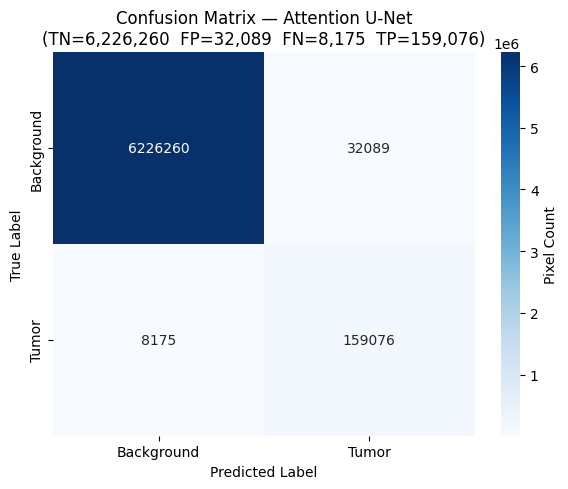


Attention U-Net Confusion Matrix breakdown:
  TN (correct background) : 6,226,260
  FP (false tumor)         : 32,089
  FN (missed tumor)        : 8,175
  TP (correct tumor)       : 159,076


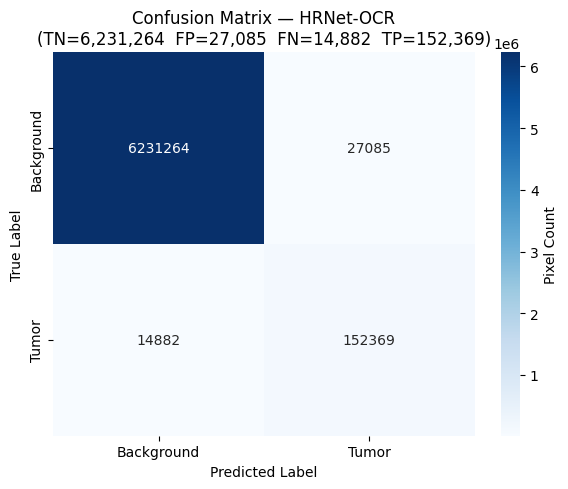


HRNet-OCR Confusion Matrix breakdown:
  TN (correct background) : 6,231,264
  FP (false tumor)         : 27,085
  FN (missed tumor)        : 14,882
  TP (correct tumor)       : 152,369

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/confusion_matrix_attention_unet.png
Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/confusion_matrix_hrnet_ocr.png


In [29]:
# ============================================================
# SECTION 14: CONFUSION MATRICES — BOTH MODELS, HIGH-RES PNG
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Background', 'Tumor'],
                yticklabels=['Background', 'Tumor'],
                cbar_kws={'label': 'Pixel Count'})
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(f'Confusion Matrix — {model_name}\n(TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,})')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n{model_name} Confusion Matrix breakdown:")
    print(f"  TN (correct background) : {tn:,}")
    print(f"  FP (false tumor)         : {fp:,}")
    print(f"  FN (missed tumor)        : {fn:,}")
    print(f"  TP (correct tumor)       : {tp:,}")
    return tn, fp, fn, tp

attn_tn, attn_fp, attn_fn, attn_tp = plot_confusion_matrix(
    attn_y_true, attn_y_pred, 'Attention U-Net',
    RESULTS_DIR / 'confusion_matrix_attention_unet.png'
)

hrnet_tn, hrnet_fp, hrnet_fn, hrnet_tp = plot_confusion_matrix(
    hrnet_y_true, hrnet_y_pred, 'HRNet-OCR',
    RESULTS_DIR / 'confusion_matrix_hrnet_ocr.png'
)

print(f"\nSaved: {RESULTS_DIR / 'confusion_matrix_attention_unet.png'}")
print(f"Saved: {RESULTS_DIR / 'confusion_matrix_hrnet_ocr.png'}")

Reproducibly selected 6 test samples (seed=42):
                           slice_path  volume  slice
 /content/data/volume_260_slice_41.h5     260     41
 /content/data/volume_313_slice_74.h5     313     74
/content/data/volume_313_slice_127.h5     313    127
 /content/data/volume_111_slice_70.h5     111     70
 /content/data/volume_111_slice_79.h5     111     79
 /content/data/volume_337_slice_66.h5     337     66


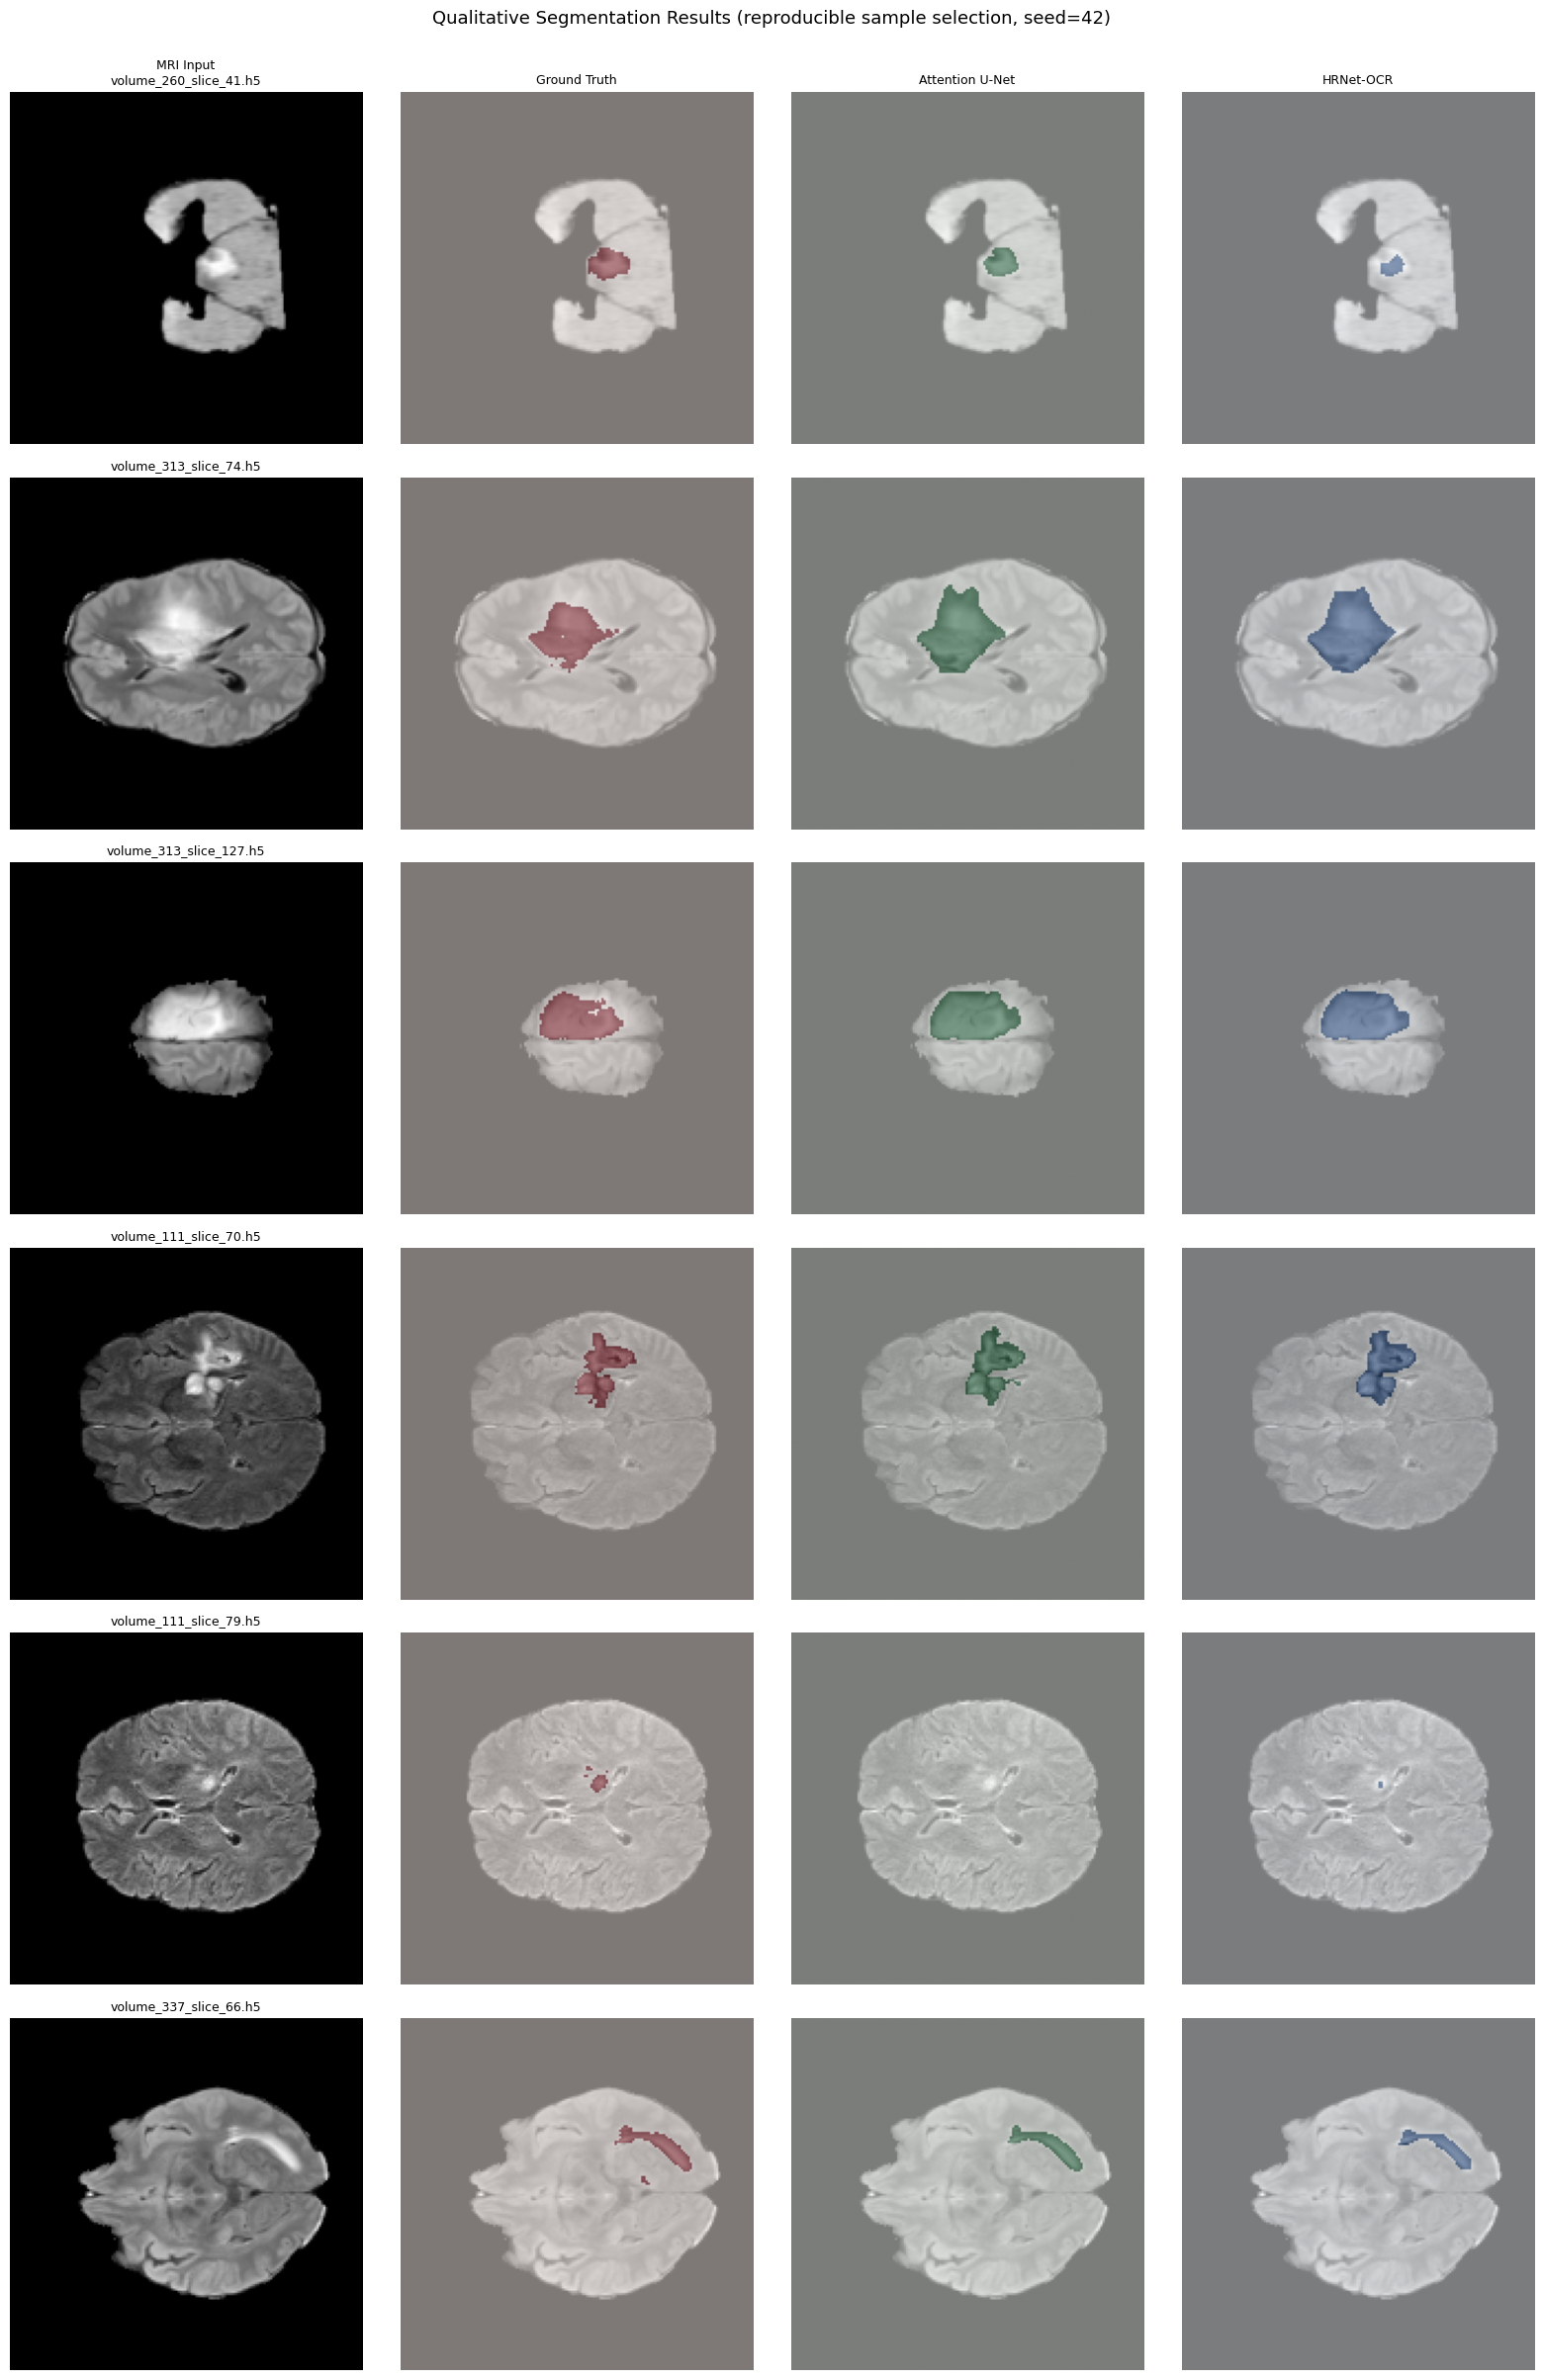


Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/qualitative_results.png


In [30]:
# ============================================================
# SECTION 15: QUALITATIVE OUTPUTS — INPUT / GT / ATTN-UNET / HRNET-OCR
# ============================================================

N_QUALITATIVE_SAMPLES = 6

# ---- Reproducible sample selection (fixed seed, not cherry-picked) ----
qual_rng = np.random.RandomState(SEED)
sample_indices = qual_rng.choice(len(test_slices_df), size=N_QUALITATIVE_SAMPLES, replace=False)
sample_indices = sorted(sample_indices)

print(f"Reproducibly selected {N_QUALITATIVE_SAMPLES} test samples (seed={SEED}):")
selected_rows = test_slices_df.iloc[sample_indices]
print(selected_rows[['slice_path', 'volume', 'slice']].to_string(index=False))

# ---- Generate predictions for each selected sample ----
fig, axes = plt.subplots(N_QUALITATIVE_SAMPLES, 4, figsize=(16, 4 * N_QUALITATIVE_SAMPLES))

for row_idx, (_, row) in enumerate(selected_rows.iterrows()):
    img, true_mask = load_and_preprocess(row['slice_path'])
    img_batch = np.expand_dims(img, axis=0)

    pred_attn = attention_unet.predict(img_batch, verbose=0)[0]
    pred_hrnet = hrnet_ocr.predict(img_batch, verbose=0)[0]

    pred_attn_binary = (pred_attn > 0.5).astype(np.float32)
    pred_hrnet_binary = (pred_hrnet > 0.5).astype(np.float32)

    fname = row['slice_path'].split('/')[-1]

    # Column 0: MRI input (channel 0)
    axes[row_idx, 0].imshow(img[..., 0], cmap='gray')
    axes[row_idx, 0].set_title(f'MRI Input\n{fname}' if row_idx == 0 else fname, fontsize=9)
    axes[row_idx, 0].axis('off')

    # Column 1: Ground truth
    axes[row_idx, 1].imshow(img[..., 0], cmap='gray')
    axes[row_idx, 1].imshow(true_mask[..., 0], cmap='Reds', alpha=0.5)
    axes[row_idx, 1].set_title('Ground Truth' if row_idx == 0 else '', fontsize=9)
    axes[row_idx, 1].axis('off')

    # Column 2: Attention U-Net prediction
    axes[row_idx, 2].imshow(img[..., 0], cmap='gray')
    axes[row_idx, 2].imshow(pred_attn_binary[..., 0], cmap='Greens', alpha=0.5)
    axes[row_idx, 2].set_title('Attention U-Net' if row_idx == 0 else '', fontsize=9)
    axes[row_idx, 2].axis('off')

    # Column 3: HRNet-OCR prediction
    axes[row_idx, 3].imshow(img[..., 0], cmap='gray')
    axes[row_idx, 3].imshow(pred_hrnet_binary[..., 0], cmap='Blues', alpha=0.5)
    axes[row_idx, 3].set_title('HRNet-OCR' if row_idx == 0 else '', fontsize=9)
    axes[row_idx, 3].axis('off')

plt.suptitle('Qualitative Segmentation Results (reproducible sample selection, seed=42)',
             fontsize=13, y=1.001)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'qualitative_results.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nSaved: {RESULTS_DIR / 'qualitative_results.png'}")

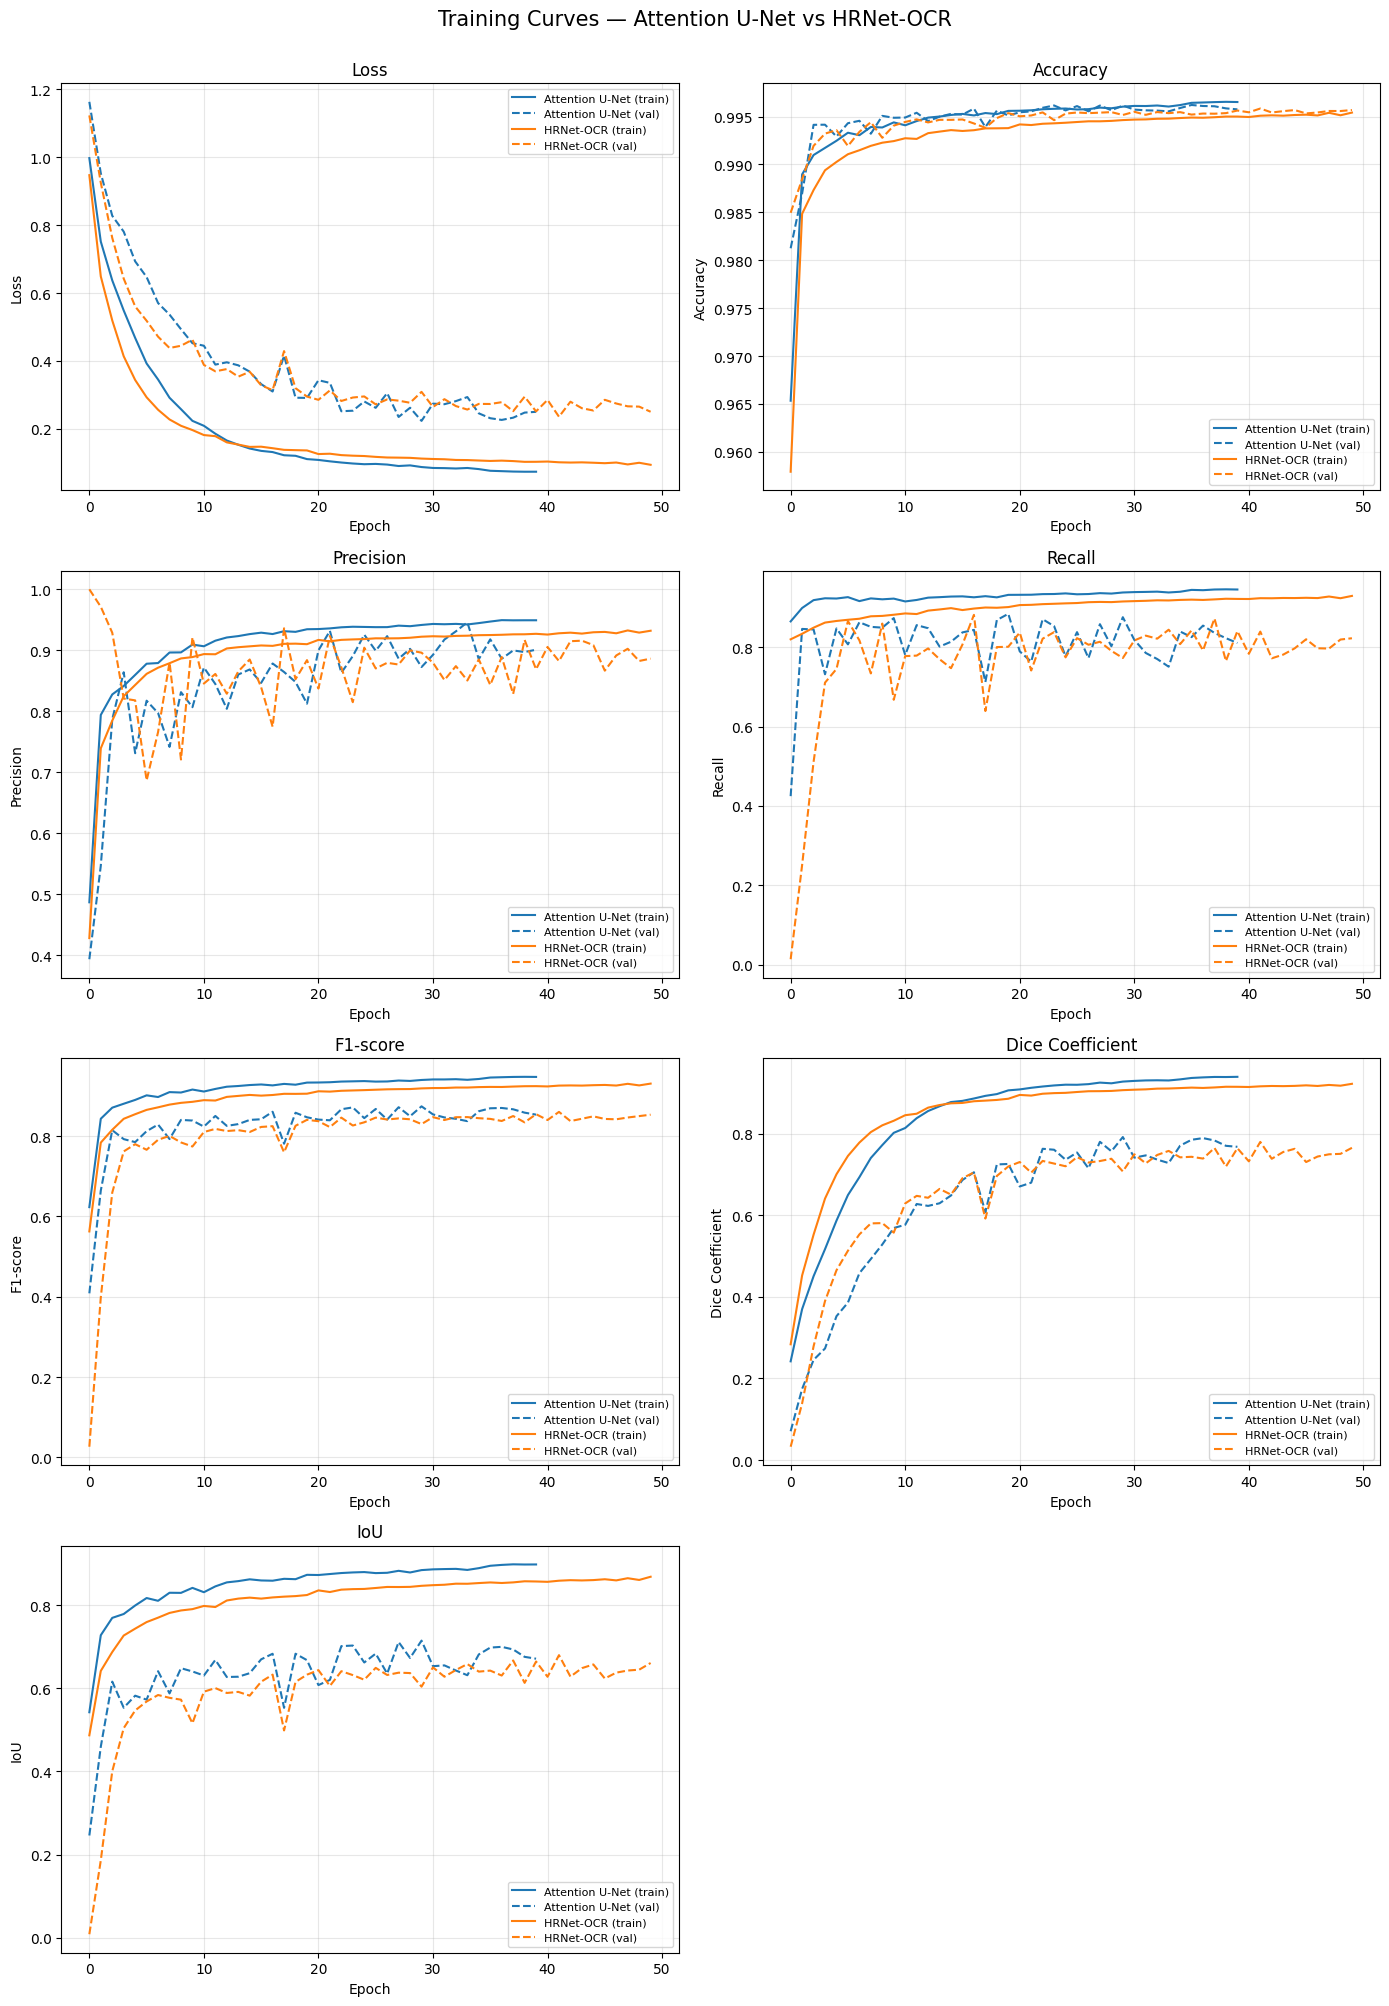

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/training_curves.png

Attention U-Net: trained for 40 epochs (early stopped)
HRNet-OCR      : trained for 50 epochs


In [31]:
# ============================================================
# SECTION 16: TRAINING CURVES — BOTH MODELS
# ============================================================

# Reload histories from Drive (guaranteed up to date regardless of session state)
with open(ARTIFACTS_DIR / 'attention_unet_history.json') as f:
    attn_hist = json.load(f)
with open(ARTIFACTS_DIR / 'hrnet_ocr_history.json') as f:
    hrnet_hist = json.load(f)

metrics_to_plot = ['loss', 'accuracy', 'precision', 'recall', 'f1_score', 'dice_coefficient', 'iou_metric']
metric_titles = ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Dice Coefficient', 'IoU']

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
    ax = axes[idx]

    if metric in attn_hist:
        ax.plot(attn_hist[metric], label='Attention U-Net (train)', color='tab:blue', linestyle='-')
        ax.plot(attn_hist[f'val_{metric}'], label='Attention U-Net (val)', color='tab:blue', linestyle='--')
    if metric in hrnet_hist:
        ax.plot(hrnet_hist[metric], label='HRNet-OCR (train)', color='tab:orange', linestyle='-')
        ax.plot(hrnet_hist[f'val_{metric}'], label='HRNet-OCR (val)', color='tab:orange', linestyle='--')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide the unused 8th subplot
axes[7].axis('off')

plt.suptitle('Training Curves — Attention U-Net vs HRNet-OCR', fontsize=15, y=1.001)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {RESULTS_DIR / 'training_curves.png'}")

# ---- Also print final epoch-count summary for the paper text ----
print(f"\nAttention U-Net: trained for {len(attn_hist['loss'])} epochs (early stopped)")
print(f"HRNet-OCR      : trained for {len(hrnet_hist['loss'])} epochs")

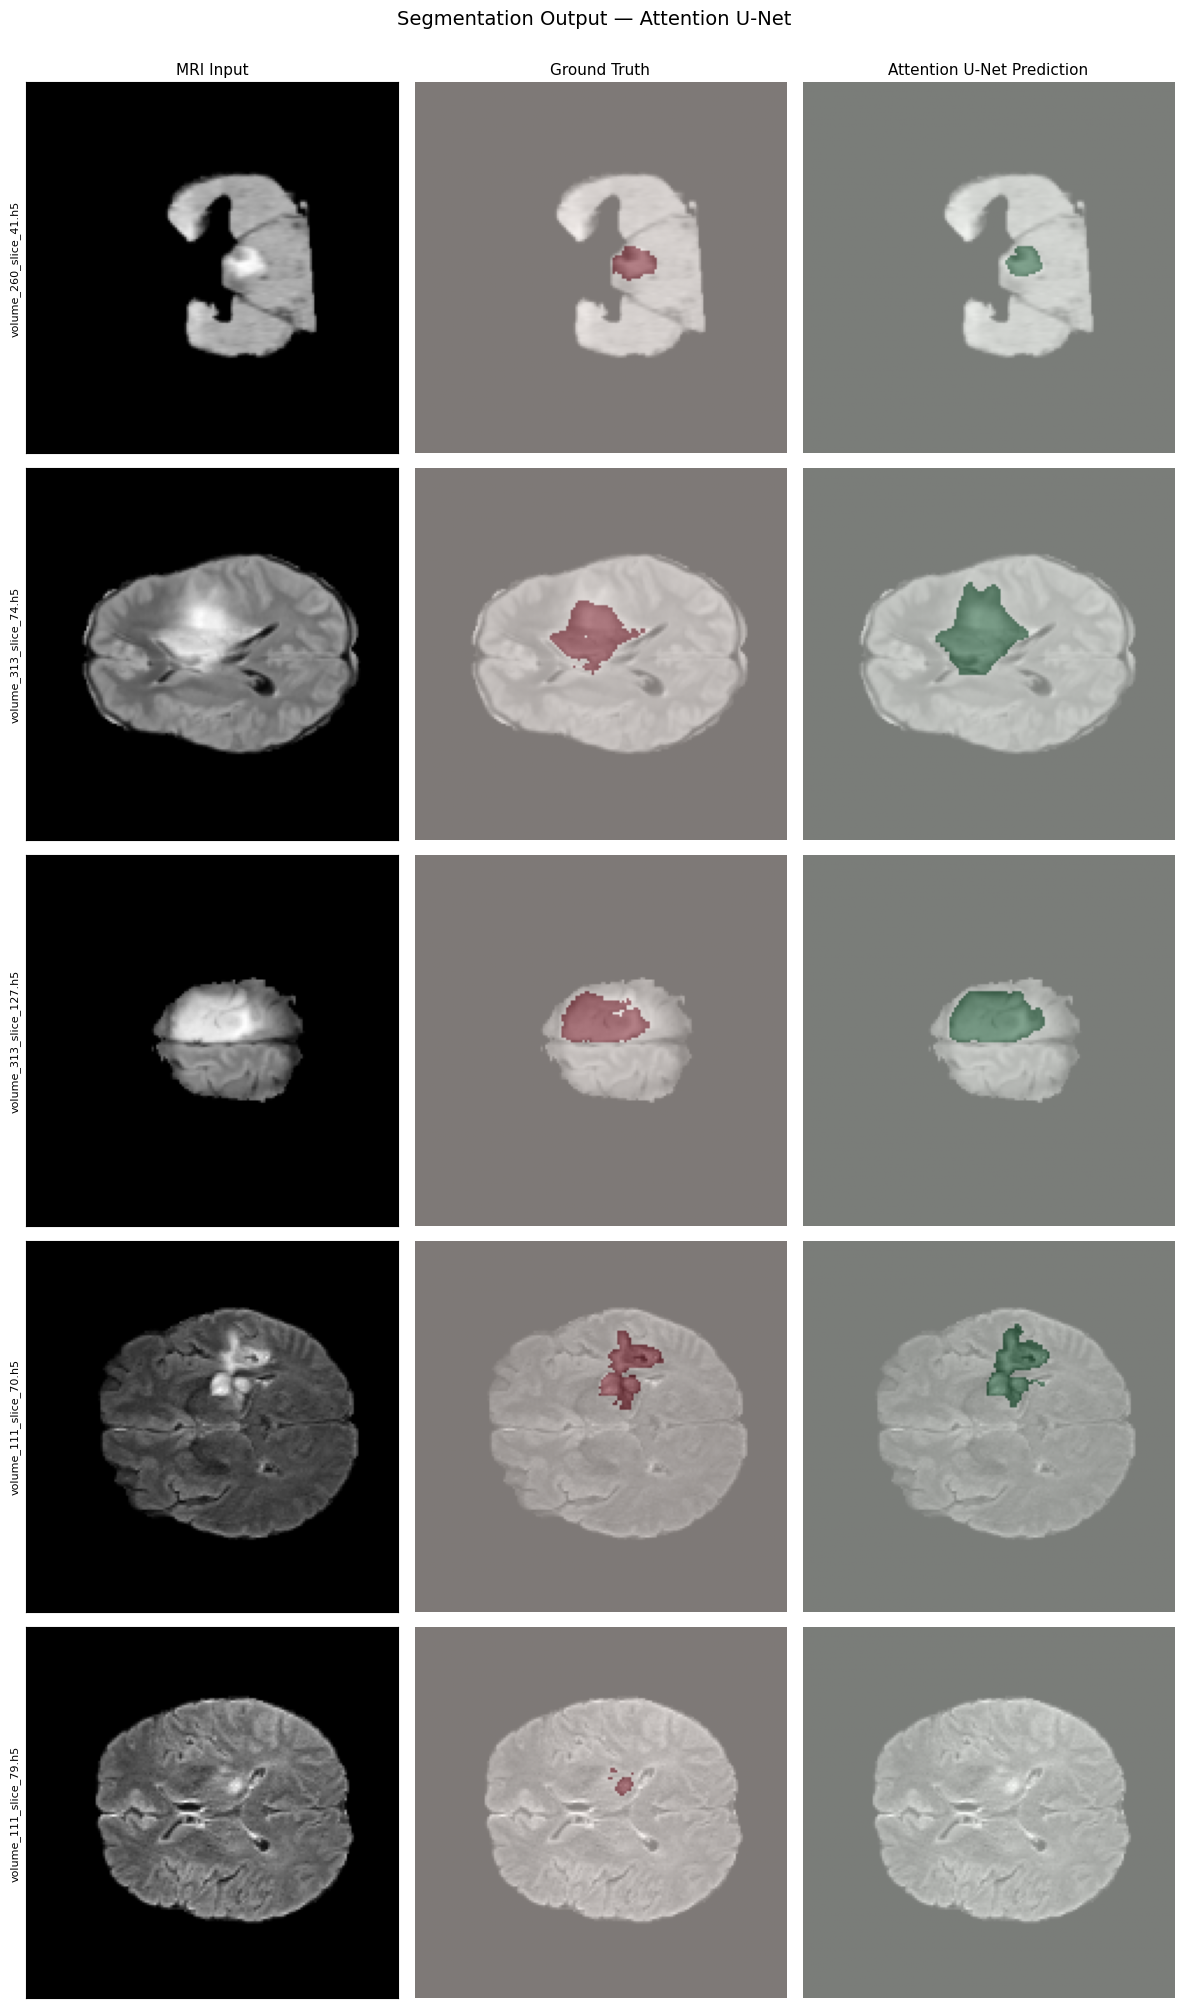

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/segmentation_output_attention_unet.png


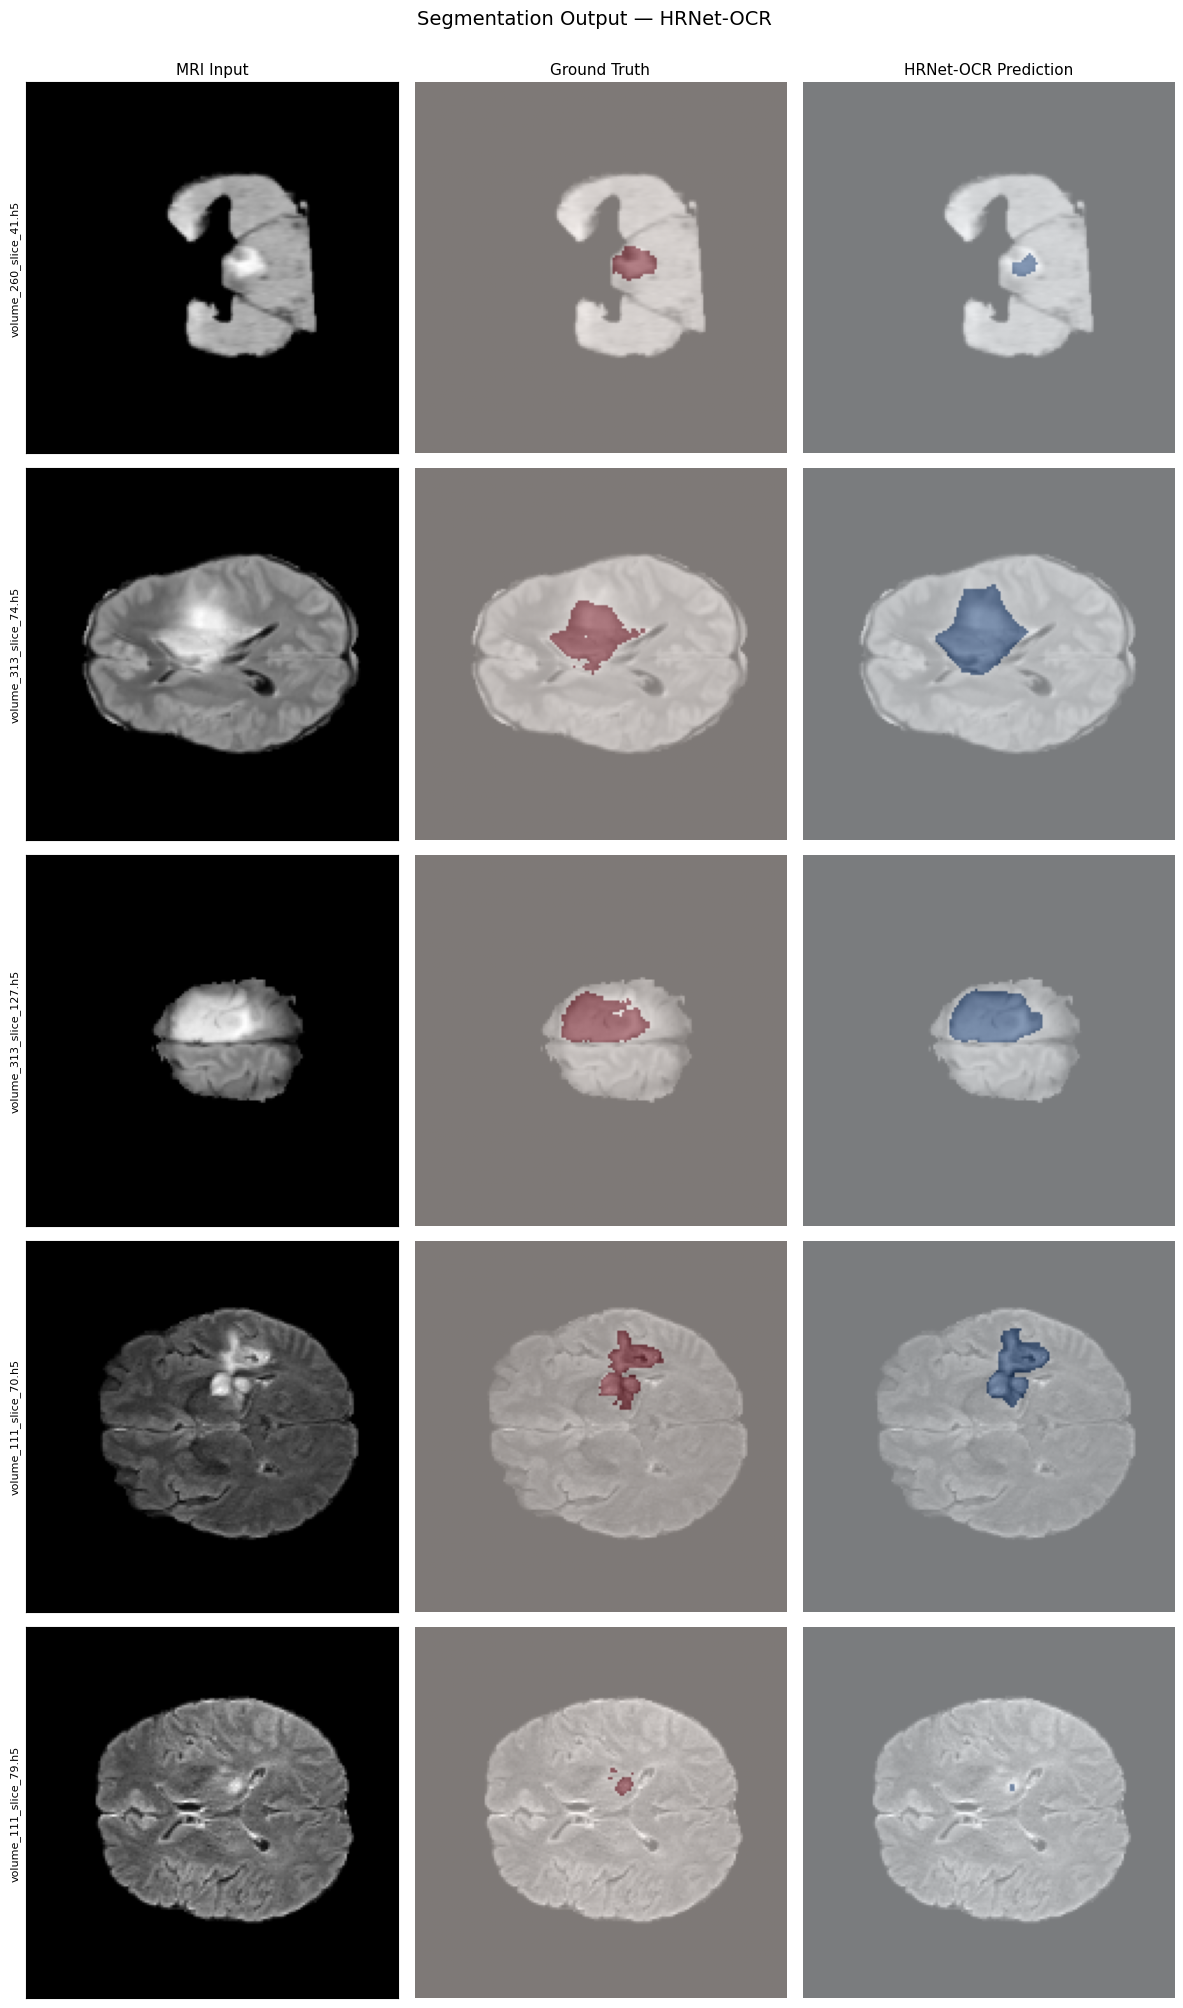

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/segmentation_output_hrnet_ocr.png


In [32]:
# ============================================================
# SEGMENTATION OUTPUT — SEPARATE FIGURE PER MODEL
# ============================================================

N_SAMPLES = 5
qual_rng = np.random.RandomState(SEED)
sample_indices = sorted(qual_rng.choice(len(test_slices_df), size=N_SAMPLES, replace=False))
selected_rows = test_slices_df.iloc[sample_indices]

def plot_model_segmentation(model, model_name, color_cmap, save_path):
    fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))

    for row_idx, (_, row) in enumerate(selected_rows.iterrows()):
        img, true_mask = load_and_preprocess(row['slice_path'])
        img_batch = np.expand_dims(img, axis=0)
        pred = model.predict(img_batch, verbose=0)[0]
        pred_binary = (pred > 0.5).astype(np.float32)
        fname = row['slice_path'].split('/')[-1]

        # Input
        axes[row_idx, 0].imshow(img[..., 0], cmap='gray')
        axes[row_idx, 0].set_title('MRI Input' if row_idx == 0 else '', fontsize=11)
        axes[row_idx, 0].set_ylabel(fname, fontsize=8)
        axes[row_idx, 0].set_xticks([]); axes[row_idx, 0].set_yticks([])

        # Ground truth
        axes[row_idx, 1].imshow(img[..., 0], cmap='gray')
        axes[row_idx, 1].imshow(true_mask[..., 0], cmap='Reds', alpha=0.5)
        axes[row_idx, 1].set_title('Ground Truth' if row_idx == 0 else '', fontsize=11)
        axes[row_idx, 1].axis('off')

        # Model's segmented output
        axes[row_idx, 2].imshow(img[..., 0], cmap='gray')
        axes[row_idx, 2].imshow(pred_binary[..., 0], cmap=color_cmap, alpha=0.5)
        axes[row_idx, 2].set_title(f'{model_name} Prediction' if row_idx == 0 else '', fontsize=11)
        axes[row_idx, 2].axis('off')

    plt.suptitle(f'Segmentation Output — {model_name}', fontsize=14, y=1.002)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

# ---- Attention U-Net segmentation output ----
plot_model_segmentation(
    attention_unet, 'Attention U-Net', 'Greens',
    RESULTS_DIR / 'segmentation_output_attention_unet.png'
)

# ---- HRNet-OCR segmentation output ----
plot_model_segmentation(
    hrnet_ocr, 'HRNet-OCR', 'Blues',
    RESULTS_DIR / 'segmentation_output_hrnet_ocr.png'
)

In [33]:
# ============================================================
# SECTION 17: FINAL CONSOLIDATED SUMMARY
# ============================================================

print("=" * 70)
print("FINAL PROJECT SUMMARY — BRAIN TUMOR SEGMENTATION")
print("=" * 70)

print(f"\nDataset: BraTS2020 (Kaggle preprocessed)")
print(f"  Total available patients : 369")
print(f"  Selected patients        : {N_PATIENTS} (stratified by grade, seed={SEED})")
print(f"  Train / Val / Test split : {len(train_slices_df.volume.unique()) if 'volume' in train_slices_df else '42'} / 9 / 9 patients")
print(f"  Tumor-positive slices    : {len(train_slices_df)} train / {len(val_slices_df)} val / {len(test_slices_df)} test")

print(f"\n{'-'*70}")
print("MODEL COMPARISON — TEST SET RESULTS")
print(f"{'-'*70}")
print(comparison_df.to_string(index=False))

print(f"\n{'-'*70}")
print("CONFUSION MATRIX SUMMARY")
print(f"{'-'*70}")
print(f"Attention U-Net -> TN={attn_tn:,}  FP={attn_fp:,}  FN={attn_fn:,}  TP={attn_tp:,}")
print(f"HRNet-OCR       -> TN={hrnet_tn:,}  FP={hrnet_fp:,}  FN={hrnet_fn:,}  TP={hrnet_tp:,}")

print(f"\n{'-'*70}")
print("TRAINING SUMMARY")
print(f"{'-'*70}")
print(f"Attention U-Net -> {len(attn_hist['loss'])} epochs, best val_loss={min(attn_hist['val_loss']):.4f}")
print(f"HRNet-OCR       -> {len(hrnet_hist['loss'])} epochs, best val_loss={min(hrnet_hist['val_loss']):.4f}")

print(f"\n{'-'*70}")
print("ALL SAVED ARTIFACTS (Drive results folder)")
print(f"{'-'*70}")
for f in sorted(RESULTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

print("=" * 70)
print("PROJECT COMPLETE — ready for paper writeup")
print("=" * 70)

FINAL PROJECT SUMMARY — BRAIN TUMOR SEGMENTATION

Dataset: BraTS2020 (Kaggle preprocessed)
  Total available patients : 369
  Selected patients        : 60 (stratified by grade, seed=42)
  Train / Val / Test split : 37 / 9 / 9 patients
  Tumor-positive slices    : 2626 train / 490 val / 251 test

----------------------------------------------------------------------
MODEL COMPARISON — TEST SET RESULTS
----------------------------------------------------------------------
          Model  Accuracy  Precision   Recall  F1-score     Dice      IoU
Attention U-Net  0.993734    0.83214 0.951121  0.887661 0.887661 0.798013
      HRNet-OCR  0.993469    0.84907 0.911020  0.878955 0.878955 0.784049

----------------------------------------------------------------------
CONFUSION MATRIX SUMMARY
----------------------------------------------------------------------
Attention U-Net -> TN=6,226,260  FP=32,089  FN=8,175  TP=159,076
HRNet-OCR       -> TN=6,231,264  FP=27,085  FN=14,882  TP=152,369

--

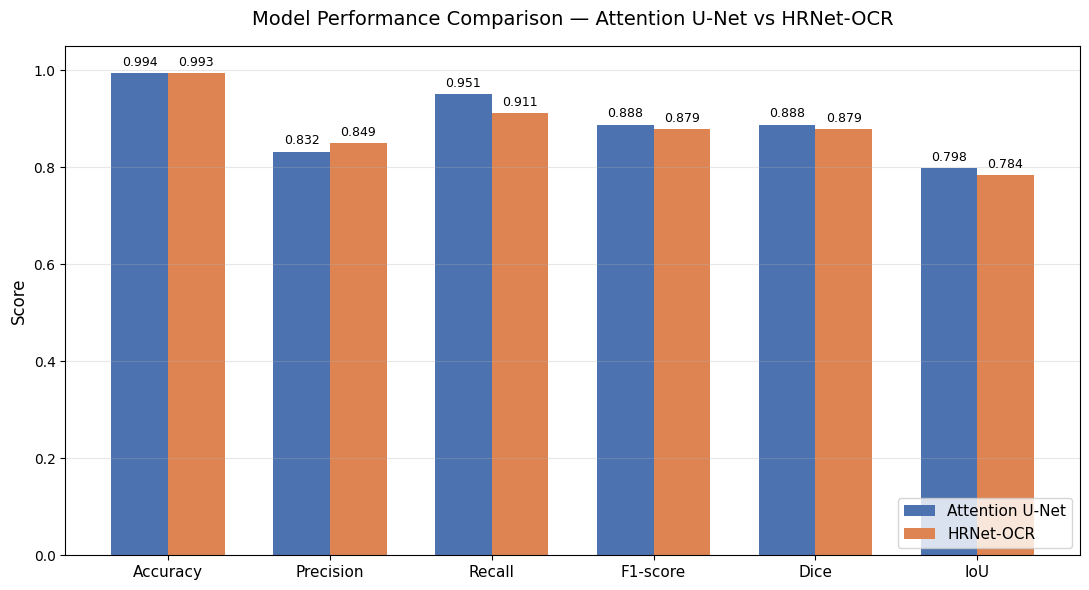

Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/model_comparison_bar_chart.png


In [34]:
# ============================================================
# MODEL PERFORMANCE COMPARISON — GROUPED BAR CHART
# ============================================================

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Dice', 'IoU']
attn_values = [attn_results[m] for m in metrics_names]
hrnet_values = [hrnet_results[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, attn_values, width, label='Attention U-Net', color='#4C72B0')
bars2 = ax.bar(x + width/2, hrnet_values, width, label='HRNet-OCR', color='#DD8452')

# Value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Attention U-Net vs HRNet-OCR', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {RESULTS_DIR / 'model_comparison_bar_chart.png'}")

Loaded Attention U-Net from: /content/drive/MyDrive/BrainTumor_project/dataset/checkpoints/attention_unet/attention_unet_best.keras
Model input shape  : (None, 160, 160, 4)
Model output shape : (None, 160, 160, 1)


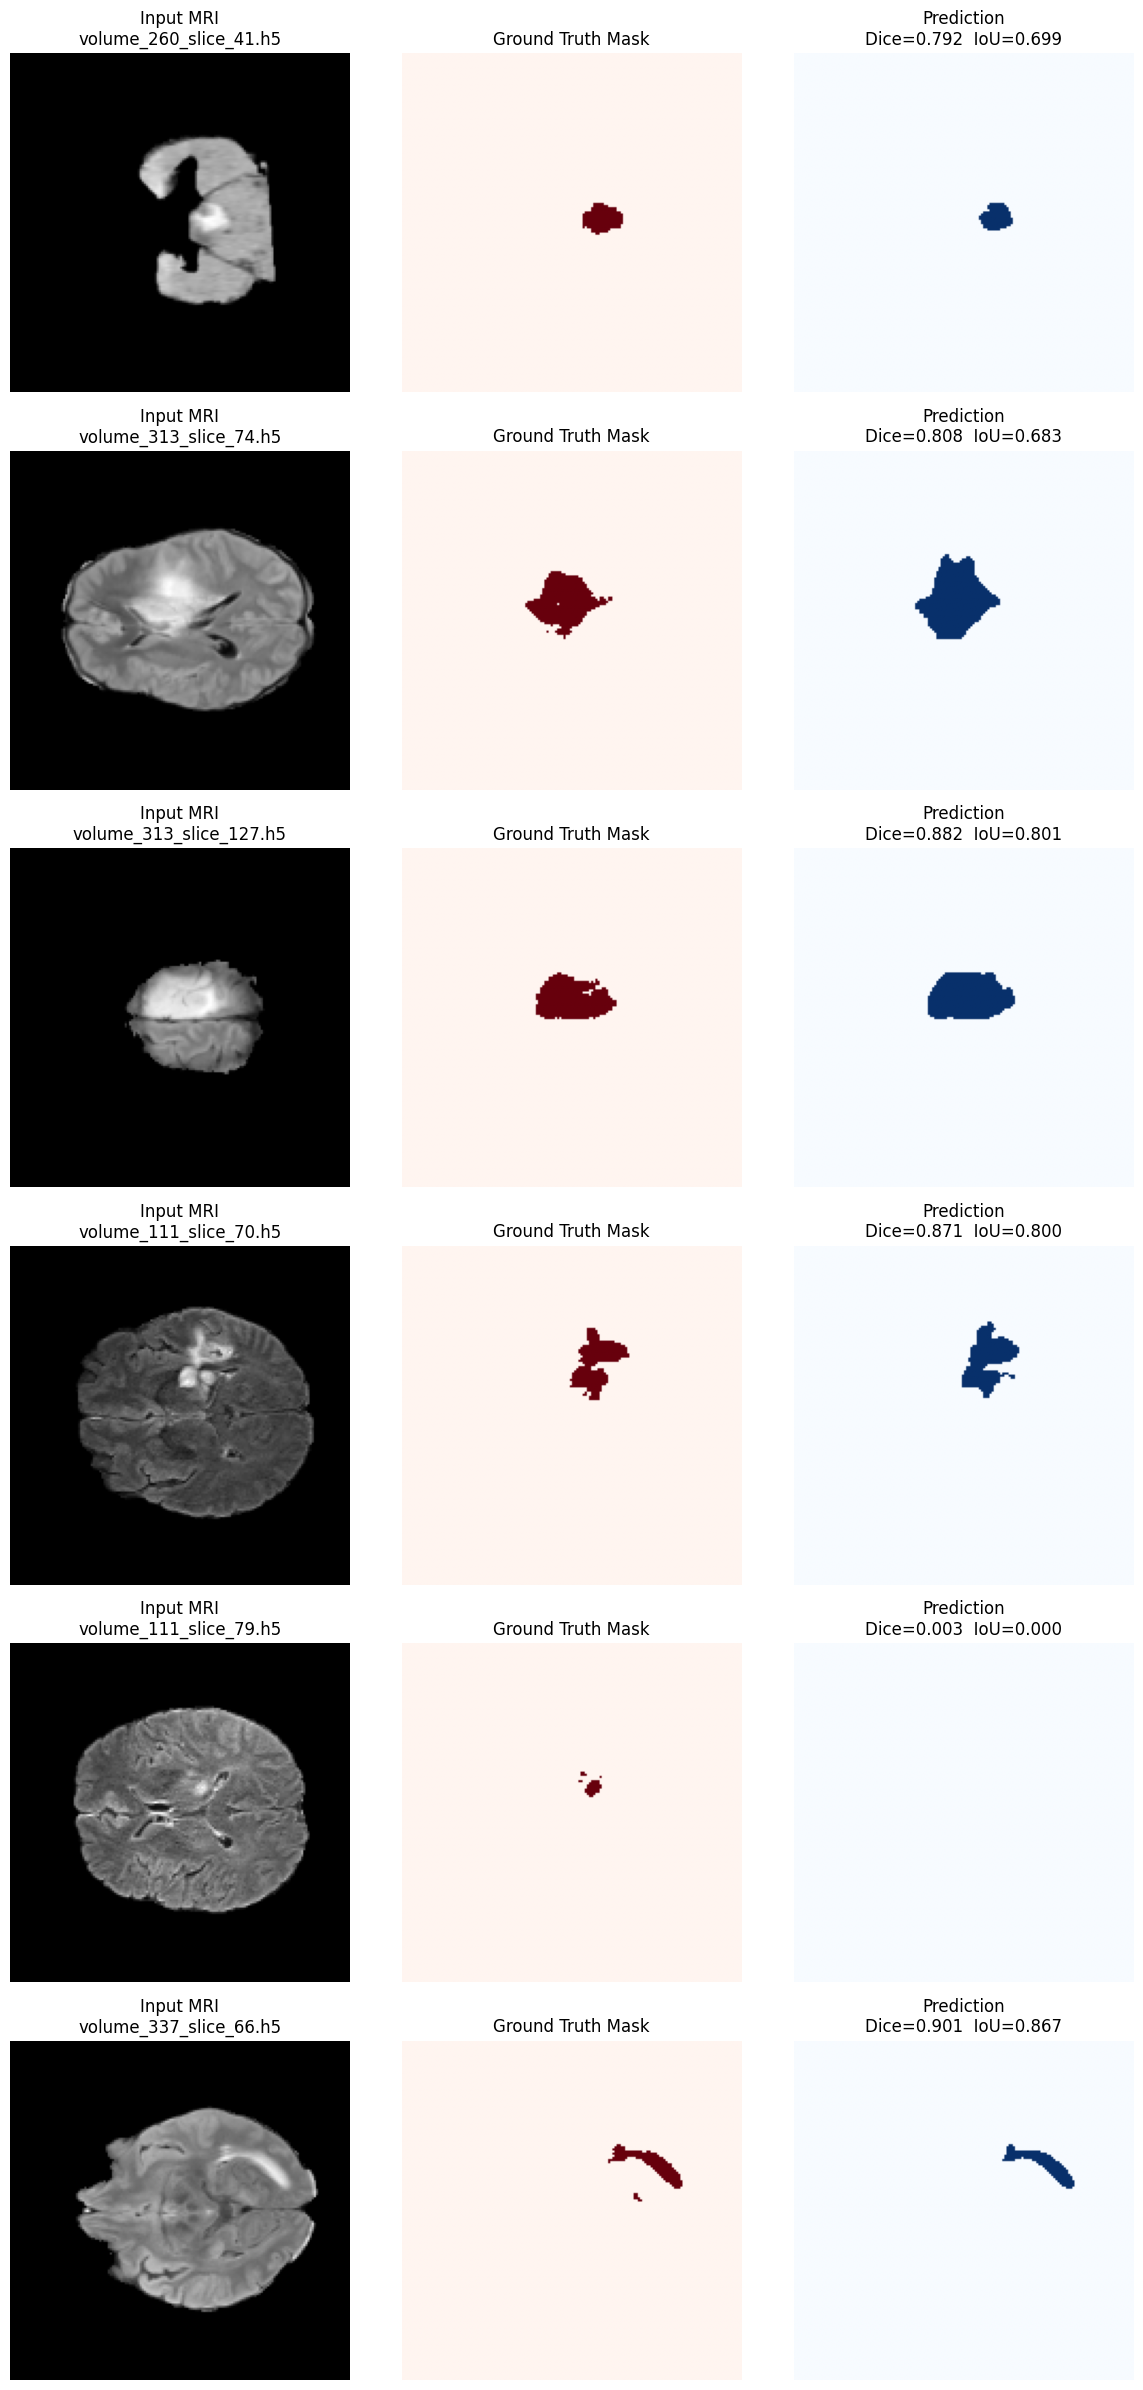


Saved: /content/drive/MyDrive/BrainTumor_project/dataset/results/attention_unet_predictions.png


In [35]:
# ============================================================
# LOAD SAVED ATTENTION U-NET AND RUN PREDICTIONS ON TEST SLICES
# ============================================================

# ---- Load the best checkpoint (saved automatically during training via ModelCheckpoint) ----
# custom_objects is required because the model was compiled with custom loss/metrics
# (combined_loss, dice_coefficient, iou_metric, F1Score) -- Keras needs these definitions
# to deserialize the .keras file correctly.
best_model_path = CHECKPOINT_DIR / 'attention_unet' / 'attention_unet_best.keras'

loaded_attn_unet = keras.models.load_model(
    best_model_path,
    custom_objects={
        'combined_loss': combined_loss,
        'dice_coefficient': dice_coefficient,
        'iou_metric': iou_metric,
        'F1Score': F1Score,
    }
)
print(f"Loaded Attention U-Net from: {best_model_path}")
print(f"Model input shape  : {loaded_attn_unet.input_shape}")
print(f"Model output shape : {loaded_attn_unet.output_shape}")

# ---- Pick a few reproducible test slices to predict on ----
N_PREDICT_SAMPLES = 6
pred_rng = np.random.RandomState(SEED)
pred_indices = sorted(pred_rng.choice(len(test_slices_df), size=N_PREDICT_SAMPLES, replace=False))
pred_rows = test_slices_df.iloc[pred_indices]

# ---- Run prediction + per-sample metrics ----
fig, axes = plt.subplots(N_PREDICT_SAMPLES, 3, figsize=(12, 4 * N_PREDICT_SAMPLES))

for i, (_, row) in enumerate(pred_rows.iterrows()):
    # load_and_preprocess already resizes to IMG_SIZE and normalizes,
    # exactly matching what the model was trained on
    img, true_mask = load_and_preprocess(row['slice_path'])

    # model expects a batch dimension: (1, IMG_SIZE, IMG_SIZE, 4)
    pred_mask = loaded_attn_unet.predict(img[np.newaxis, ...], verbose=0)[0]
    pred_binary = (pred_mask > 0.5).astype(np.uint8)

    # per-sample Dice/IoU, using the same functions used during training
    dice_val = float(dice_coefficient(true_mask[np.newaxis, ...], pred_mask[np.newaxis, ...]))
    iou_val  = float(iou_metric(true_mask[np.newaxis, ...], pred_mask[np.newaxis, ...]))

    fname = row['slice_path'].split('/')[-1]

    # display channel 0 (e.g. FLAIR/T1 depending on stacking order) as the background image
    axes[i, 0].imshow(img[..., 0], cmap='gray')
    axes[i, 0].set_title(f"Input MRI\n{fname}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(true_mask[..., 0], cmap='Reds')
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_binary[..., 0], cmap='Blues')
    axes[i, 2].set_title(f"Prediction\nDice={dice_val:.3f}  IoU={iou_val:.3f}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'attention_unet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {RESULTS_DIR / 'attention_unet_predictions.png'}")